# EX03. ResNet Ablation Study

## 프로젝트 목적

이 프로젝트에서는 ResNet의 핵심 구조인 residual connection을 직접 구현하고,
동일한 깊이의 PlainNet과 비교하여 residual connection의 효과를 확인한다.

## 구현 모델

| 모델 | 블록 종류 | Stage Config | Skip Connection |
|---|---|---|---|
| PlainNet-34 | Basic Block | [3, 4, 6, 3] | 사용하지 않음 |
| ResNet-34 | Basic Block | [3, 4, 6, 3] | 사용 |
| PlainNet-50 | Bottleneck Block | [3, 4, 6, 3] | 사용하지 않음 |
| ResNet-50 | Bottleneck Block | [3, 4, 6, 3] | 사용 |

## Ablation Study 가설

동일한 깊이와 동일한 학습 조건에서 residual connection을 사용하는
ResNet이 residual connection을 제거한 PlainNet보다 안정적으로 학습될 것이다.

이를 다음 지표로 비교한다.

- Training loss
- Validation loss
- Training accuracy
- Validation accuracy
- Best validation accuracy
- 학습 시간
- 모델 파라미터 수

## 프로젝트 루브릭

1. ResNet-34와 ResNet-50의 블록 및 전체 모델을 정상적으로 구현한다.
2. 모델 summary와 dummy input forward 결과를 통해 구조를 검증한다.
3. torchvision 데이터셋으로 학습했을 때 loss 감소를 확인한다.
4. PlainNet과 ResNet을 동일한 epoch와 조건으로 학습한다.
5. Validation accuracy를 기준으로 Ablation Study 결과표를 작성한다.

## 실행 전략: colab 자원을 아껴쓰자!

### CPU 단계

- 라이브러리 및 버전 확인
- Google Drive 경로 설정
- 데이터셋 구조 확인
- Basic Block 및 Bottleneck Block 구현
- 네 모델 생성
- 모델 summary 출력
- Dummy input forward 검증
- 소규모 학습 코드 점검

### GPU 단계

- 소규모 Smoke Test
- 네 모델 순차 학습
- History 및 checkpoint 저장
- Validation accuracy와 loss 비교
- 결과 그래프 및 Ablation Study 표 작성

# 1. 라이브러리 및 실행 환경 확인

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# 2. 경로/시드/디바이스 설정

In [3]:
from pathlib import Path

# 프로젝트 최상위 경로
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher"
)

# 노트북 경로
NOTEBOOK_PATH = PROJECT_ROOT / "EX03_resnet_ablation_study.ipynb"

# 데이터 루트
# 현재는 비어 있으며, 이후 torchvision이 필요한 하위 구조를 생성한다.
DATA_DIR = PROJECT_ROOT / "data"

# 모델 checkpoint 저장 경로
MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "EX03_resnet_ablation"
)

# 출력 결과 최상위 경로
OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "EX03_resnet_ablation"
)

# 세부 출력 경로
SUMMARY_DIR = OUTPUT_DIR / "summaries"
HISTORY_DIR = OUTPUT_DIR / "histories"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "results"
SPLIT_DIR = OUTPUT_DIR / "splits"

In [4]:
PROJECT_PATHS = {
    "PROJECT_ROOT": PROJECT_ROOT,
    "NOTEBOOK_PATH": NOTEBOOK_PATH,
    "DATA_DIR": DATA_DIR,
    "MODEL_DIR": MODEL_DIR,
    "OUTPUT_DIR": OUTPUT_DIR,
    "SUMMARY_DIR": SUMMARY_DIR,
    "HISTORY_DIR": HISTORY_DIR,
    "FIGURE_DIR": FIGURE_DIR,
    "RESULT_DIR": RESULT_DIR,
    "SPLIT_DIR": SPLIT_DIR,
}

for name, path in PROJECT_PATHS.items():
    status = "존재함" if path.exists() else "없음"
    print(f"{name:14s} | {status:4s} | {path}")

PROJECT_ROOT   | 존재함  | /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher
NOTEBOOK_PATH  | 없음   | /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/EX03_resnet_ablation_study.ipynb
DATA_DIR       | 존재함  | /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data
MODEL_DIR      | 존재함  | /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/EX03_resnet_ablation
OUTPUT_DIR     | 존재함  | /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation
SUMMARY_DIR    | 존재함  | /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/summaries
HISTORY_DIR    | 존재함  | /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/histories
FIGURE_DIR     | 존재함  | /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/figures
RESULT_DIR     | 존재함  | /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_res

(이번에는 경로 세팅에 애를 좀 먹었습니다. 비교할 게 많아서...)

In [5]:
print("[PROJECT_ROOT 하위 항목]")

for path in sorted(PROJECT_ROOT.iterdir()):
    item_type = "폴더" if path.is_dir() else "파일"
    print(f"- [{item_type}] {path.name}")

[PROJECT_ROOT 하위 항목]
- [파일] EX02_human_segmentation_final.ipynb
- [파일] [In progress] EX03_resnet_ablation_study.ipynb
- [폴더] data
- [폴더] models
- [폴더] outputs
- [폴더] 이전 예제


In [6]:
data_items = list(DATA_DIR.iterdir())

print(f"DATA_DIR: {DATA_DIR}")
print(f"현재 항목 수: {len(data_items)}")

if len(data_items) == 0:
    print("data 폴더가 비어 있습니다. 정상적인 초기 상태입니다.")
else:
    print("data 폴더 내부 항목:")
    for path in sorted(data_items):
        print(f"- {path.name}")

DATA_DIR: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data
현재 항목 수: 1
data 폴더 내부 항목:
- oxford-iiit-pet


In [2]:
import sys
import platform

import numpy as np
import torch
import torchvision

print("Python      :", sys.version.split()[0])
print("Platform    :", platform.platform())
print("PyTorch     :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("NumPy       :", np.__version__)

Python      : 3.12.13
Platform    : Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch     : 2.11.0+cu128
Torchvision : 0.26.0+cu128
NumPy       : 2.0.2


In [9]:
import os
import random

SEED = 42


def set_seed(seed: int = 42) -> None:
    """Python, NumPy, PyTorch의 난수 시드를 고정한다."""

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # 재현성을 우선하는 설정
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

print(f"Random seed: {SEED}")

Random seed: 42


In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("현재 실행 장치:", device)

if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))
else:
    print("현재는 CPU 단계입니다.")

현재 실행 장치: cuda
GPU 이름: Tesla T4


In [10]:
#초기 설정값 기록
PROJECT_CONFIG = {
    "project_name": "EX03_resnet_ablation",
    "seed": SEED,
    "input_height": 224,
    "input_width": 224,
    "input_channels": 3,
    "dataset": "OxfordIIITPet",
    "device_at_setup": str(device),
}

PROJECT_CONFIG

{'project_name': 'EX03_resnet_ablation',
 'seed': 42,
 'input_height': 224,
 'input_width': 224,
 'input_channels': 3,
 'dataset': 'OxfordIIITPet',
 'device_at_setup': 'cuda'}

# 3. 데이터셋 준비

## 3-1. 데이터셋 구성 전략

이 프로젝트에서는 `torchvision.datasets.OxfordIIITPet`을 사용한다.

- 입력 이미지 크기: 224 × 224
- 분류 대상: 37개 반려동물 품종
- 학습 원본: 공식 `trainval` split
- 검증 데이터: `trainval`에서 seed 42로 분리
- 공식 `test` split: 이번 Ablation Study의 학습 및 검증에는 사용하지 않음

*중요 사항!!!*
PlainNet과 ResNet의 공정한 비교를 위해 네 모델 모두 동일한
train/validation index를 사용한다.

데이터 분할 index는 다음 경로에 저장한다.

`outputs/EX03_resnet_ablation/splits/`

이번 프로젝트의 비교 기준이 validation accuracy이므로 다음 구조로 구분한겁니다.

공식 trainval

├── Train

└── Validation

공식 test

└── 최종 테스트용으로 보존

(근데 이 경로 도식 줄갈이 안해도 행갈이 되게끔 하는 방법없을까요. 이글을 읽으시는 마크다운 고수 그루님, 퍼실님 팁 구합니다..)

In [11]:
from torchvision.datasets import OxfordIIITPet

# transform을 적용하기 전의 원본 데이터셋
# 이후 동일한 index에 서로 다른 train/validation transform을 적용한다.
raw_dataset = OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="category",
    transform=None,
    download=True,
)

print("데이터셋 다운로드 및 로드 완료")
print(f"전체 샘플 수 : {len(raw_dataset):,}")
print(f"클래스 수    : {len(raw_dataset.classes)}")
print(f"첫 번째 클래스: {raw_dataset.classes[0]}")
print(f"마지막 클래스 : {raw_dataset.classes[-1]}")

데이터셋 다운로드 및 로드 완료
전체 샘플 수 : 3,680
클래스 수    : 37
첫 번째 클래스: Abyssinian
마지막 클래스 : Yorkshire Terrier


In [17]:
#데이터셋 메타데이터 확인 - 제발 잘 나와라. 이 값은 아마 나중에 classifier의 마지막 출력 차원에 사용합니다!.
NUM_CLASSES = len(raw_dataset.classes)
CLASS_NAMES = raw_dataset.classes

print(f"NUM_CLASSES: {NUM_CLASSES}")
print("\n[클래스 목록]")

for class_index, class_name in enumerate(CLASS_NAMES):
    print(f"{class_index:2d}: {class_name}")

NUM_CLASSES: 37

[클래스 목록]
 0: Abyssinian
 1: American Bulldog
 2: American Pit Bull Terrier
 3: Basset Hound
 4: Beagle
 5: Bengal
 6: Birman
 7: Bombay
 8: Boxer
 9: British Shorthair
10: Chihuahua
11: Egyptian Mau
12: English Cocker Spaniel
13: English Setter
14: German Shorthaired
15: Great Pyrenees
16: Havanese
17: Japanese Chin
18: Keeshond
19: Leonberger
20: Maine Coon
21: Miniature Pinscher
22: Newfoundland
23: Persian
24: Pomeranian
25: Pug
26: Ragdoll
27: Russian Blue
28: Saint Bernard
29: Samoyed
30: Scottish Terrier
31: Shiba Inu
32: Siamese
33: Sphynx
34: Staffordshire Bull Terrier
35: Wheaten Terrier
36: Yorkshire Terrier


In [ ]:
#원본 샘플 확인
sample_image, sample_label = raw_dataset[0]

print("이미지 자료형 :", type(sample_image))
print("원본 이미지 크기:", sample_image.size)
print("레이블 번호    :", sample_label)
print("레이블 이름    :", CLASS_NAMES[sample_label])

이미지 자료형 : <class 'PIL.Image.Image'>
원본 이미지 크기: (394, 500)
레이블 번호    : 0
레이블 이름    : Abyssinian


In [ ]:
#구조 확인
from pathlib import Path


def summarize_directory(directory: Path) -> None:
    """최상위 폴더와 각 하위 폴더의 파일 개수만 출력한다."""

    print(f"[데이터 루트] {directory}")

    for path in sorted(directory.iterdir()):
        if path.is_file():
            print(f"- 파일: {path.name}")
            continue

        file_count = sum(
            1 for item in path.rglob("*")
            if item.is_file()
        )

        print(
            f"- 폴더: {path.name:20s} | "
            f"내부 파일 수: {file_count:,}"
        )


summarize_directory(DATA_DIR)

[데이터 루트] /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data
- 폴더: oxford-iiit-pet      | 내부 파일 수: 25,866


### Train·Validation 분할

공식 `trainval` 데이터 3,680장을 다음과 같이 분할한다.

- Train: 80%
- Validation: 20%
- Random seed: 42
- 분할 방식: 클래스 비율을 유지하는 stratified split

Ablation Study의 공정성과 재현성을 위해 분할 index는 최초 한 번만
생성하고 JSON 파일로 저장한다.

저장 경로:

`outputs/EX03_resnet_ablation/splits/oxford_pet_trainval_split_seed42.json`

이후 네 모델은 모두 같은 train/validation index를 사용한다.

In [15]:
import numpy as np

# torchvision OxfordIIITPet 내부 레이블을 우선 사용한다.
# 버전에 따라 내부 속성이 없을 경우 데이터셋을 순회해 가져온다.
if hasattr(raw_dataset, "_labels"):
    all_labels = np.asarray(raw_dataset._labels)
else:
    all_labels = np.asarray([
        raw_dataset[index][1]
        for index in range(len(raw_dataset))
    ])

print("전체 레이블 수 :", len(all_labels))
print("최소 레이블 번호:", all_labels.min())
print("최대 레이블 번호:", all_labels.max())
print("고유 클래스 수  :", len(np.unique(all_labels)))

전체 레이블 수 : 3680
최소 레이블 번호: 0
최대 레이블 번호: 36
고유 클래스 수  : 37


In [12]:
#층화 분할 생성 및 저장
import json

from sklearn.model_selection import train_test_split


SPLIT_FILE = (
    SPLIT_DIR
    / f"oxford_pet_trainval_split_seed{SEED}.json"
)

all_indices = np.arange(len(raw_dataset))


if SPLIT_FILE.exists():
    # 이전에 만든 동일한 분할 재사용
    with open(SPLIT_FILE, "r", encoding="utf-8") as file:
        split_data = json.load(file)

    train_indices = split_data["train_indices"]
    val_indices = split_data["val_indices"]

    print("저장된 분할 index를 불러왔습니다.")

else:
    # 클래스 비율을 유지하는 80:20 분할
    train_indices, val_indices = train_test_split(
        all_indices,
        test_size=0.20,
        random_state=SEED,
        shuffle=True,
        stratify=all_labels,
    )

    # JSON 저장을 위해 NumPy 정수를 Python int로 변환
    train_indices = [
        int(index) for index in train_indices
    ]
    val_indices = [
        int(index) for index in val_indices
    ]

    split_data = {
        "dataset": "OxfordIIITPet",
        "source_split": "trainval",
        "seed": SEED,
        "validation_ratio": 0.20,
        "total_size": len(raw_dataset),
        "train_size": len(train_indices),
        "validation_size": len(val_indices),
        "num_classes": NUM_CLASSES,
        "train_indices": train_indices,
        "val_indices": val_indices,
    }

    with open(SPLIT_FILE, "w", encoding="utf-8") as file:
        json.dump(
            split_data,
            file,
            ensure_ascii=False,
            indent=2,
        )

    print("새로운 분할 index를 생성하고 저장했습니다.")


print(f"Train 샘플 수     : {len(train_indices):,}")
print(f"Validation 샘플 수: {len(val_indices):,}")
print(f"분할 파일         : {SPLIT_FILE}")

저장된 분할 index를 불러왔습니다.
Train 샘플 수     : 2,944
Validation 샘플 수: 736
분할 파일         : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/splits/oxford_pet_trainval_split_seed42.json


In [13]:
#중요!! 분할 무결성 검증

train_index_set = set(train_indices)
val_index_set = set(val_indices)

assert train_index_set.isdisjoint(val_index_set), (
    "Train과 validation index가 겹칩니다."
)

assert (
    len(train_indices) + len(val_indices)
    == len(raw_dataset)
), "분할된 샘플 수가 전체 데이터 수와 다릅니다."

assert (
    train_index_set | val_index_set
    == set(range(len(raw_dataset)))
), "분할 과정에서 누락된 index가 있습니다."

print("분할 무결성 검증 완료")
print("- Train/Validation 중복 없음")
print("- 누락된 데이터 없음")
print("- 전체 샘플 수 일치")

분할 무결성 검증 완료
- Train/Validation 중복 없음
- 누락된 데이터 없음
- 전체 샘플 수 일치


In [18]:
#클래스별 분포 확인
from collections import Counter

train_class_counts = Counter(
    int(all_labels[index])
    for index in train_indices
)

val_class_counts = Counter(
    int(all_labels[index])
    for index in val_indices
)

print(
    f"Train 클래스별 최소/최대 샘플 수: "
    f"{min(train_class_counts.values())} / "
    f"{max(train_class_counts.values())}"
)

print(
    f"Validation 클래스별 최소/최대 샘플 수: "
    f"{min(val_class_counts.values())} / "
    f"{max(val_class_counts.values())}"
)

print("\n[앞의 5개 클래스 분포]")

for class_index in range(5):
    print(
        f"{class_index:2d} "
        f"{CLASS_NAMES[class_index]:30s} | "
        f"train={train_class_counts[class_index]:3d}, "
        f"val={val_class_counts[class_index]:3d}"
    )

Train 클래스별 최소/최대 샘플 수: 74 / 80
Validation 클래스별 최소/최대 샘플 수: 19 / 20

[앞의 5개 클래스 분포]
 0 Abyssinian                     | train= 80, val= 20
 1 American Bulldog               | train= 80, val= 20
 2 American Pit Bull Terrier      | train= 80, val= 20
 3 Basset Hound                   | train= 80, val= 20
 4 Beagle                         | train= 80, val= 20


In [19]:
#이미지 전처리 정의. 모델 입력인 224x224로 바꾸고 텐서로 변환하는 일
from torchvision import transforms


IMAGE_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        size=IMAGE_SIZE,
        scale=(0.80, 1.00),
    ),
    transforms.RandomHorizontalFlip(
        p=0.5,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


print("[Train transform]")
print(train_transform)

print("\n[Validation transform]")
print(val_transform)

#Validation에 무작위 변환을 넣으면 평가할 때마다 결과가 달라질 수 있으므로 사용하지 않음..!

[Train transform]
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

[Validation transform]
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [20]:
#동일한 원본 데이터에 서로 다른 transform 적용. 분할 인덱스는 같지만 학습과 검증의 전처리는 다르기 때문에 데이터셋 객체 두개 필요
from torch.utils.data import Subset
from torchvision.datasets import OxfordIIITPet


train_base_dataset = OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="category",
    transform=train_transform,
    download=False,
)

val_base_dataset = OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="category",
    transform=val_transform,
    download=False,
)


train_dataset = Subset(
    train_base_dataset,
    train_indices,
)

val_dataset = Subset(
    val_base_dataset,
    val_indices,
)


print(f"Train dataset     : {len(train_dataset):,}")
print(f"Validation dataset: {len(val_dataset):,}")

Train dataset     : 2,944
Validation dataset: 736


In [21]:
#한배치만 점검
from torch.utils.data import DataLoader


preview_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

preview_images, preview_labels = next(
    iter(preview_loader)
)

print("이미지 batch shape:", preview_images.shape)
print("레이블 batch shape:", preview_labels.shape)
print("레이블 번호       :", preview_labels.tolist())
print(
    "레이블 이름       :",
    [
        CLASS_NAMES[label]
        for label in preview_labels.tolist()
    ],
)

이미지 batch shape: torch.Size([4, 3, 224, 224])
레이블 batch shape: torch.Size([4])
레이블 번호       : [33, 19, 5, 34]
레이블 이름       : ['Sphynx', 'Leonberger', 'Bengal', 'Staffordshire Bull Terrier']


# 4. ResNet 구조 설계

이번 프로젝트에서는 같은 블록 코드에서 use_residual 인자를 사용해 다음 두 모델을 생성할 수 있도록 설계한다.

**use_residual=True**: ResNet

**use_residual=False**: PlainNet

## 4-1. BasicBlock


In [22]:
from __future__ import annotations

import torch
from torch import nn


class BasicBlock(nn.Module):
    """
    ResNet-34와 PlainNet-34에 사용하는 기본 블록.

    residual=True:
        y = ReLU(F(x) + shortcut(x))

    residual=False:
        y = ReLU(F(x))
    """

    # BasicBlock은 출력 채널을 확장하지 않는다.
    expansion: int = 1

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int = 1,
        use_residual: bool = True,
    ) -> None:
        super().__init__()

        self.use_residual = use_residual

        # -----------------------------------
        # 주 경로 F(x)
        # -----------------------------------
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        # -----------------------------------
        # Shortcut 경로
        # -----------------------------------
        if self.use_residual:
            shape_changes = (
                stride != 1
                or in_channels != out_channels
            )

            if shape_changes:
                self.shortcut = nn.Sequential(
                    nn.Conv2d(
                        in_channels=in_channels,
                        out_channels=out_channels,
                        kernel_size=1,
                        stride=stride,
                        bias=False,
                    ),
                    nn.BatchNorm2d(out_channels),
                )
            else:
                self.shortcut = nn.Identity()

        else:
            # PlainNet에서는 shortcut을 사용하지 않는다.
            self.shortcut = None

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        # -----------------------------------
        # F(x) 계산
        # -----------------------------------
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # -----------------------------------
        # Residual connection
        # -----------------------------------
        if self.use_residual:
            identity = self.shortcut(x)
            out = out + identity

        # ResNet v1의 post-activation
        out = self.relu(out)

        return out

In [ ]:
#basic block 입출력 shape이 같은 경우 확인
basic_block_same = BasicBlock(
    in_channels=64,
    out_channels=64,
    stride=1,
    use_residual=True,
)

dummy_same = torch.randn(
    2,
    64,
    56,
    56,
)

with torch.no_grad():
    output_same = basic_block_same(dummy_same)

print("입력 shape :", dummy_same.shape)
print("출력 shape :", output_same.shape)
print("Shortcut   :", basic_block_same.shortcut)

입력 shape : torch.Size([2, 64, 56, 56])
출력 shape : torch.Size([2, 64, 56, 56])
Shortcut   : Identity()


In [ ]:
#채널과 공간 크기가 변하는 경우
basic_block_downsample = BasicBlock(
    in_channels=64,
    out_channels=128,
    stride=2,
    use_residual=True,
)

dummy_downsample = torch.randn(
    2,
    64,
    56,
    56,
)

with torch.no_grad():
    output_downsample = basic_block_downsample(
        dummy_downsample
    )

print("입력 shape :", dummy_downsample.shape)
print("출력 shape :", output_downsample.shape)
print("Shortcut:")
print(basic_block_downsample.shortcut)

입력 shape : torch.Size([2, 64, 56, 56])
출력 shape : torch.Size([2, 128, 28, 28])
Shortcut:
Sequential(
  (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
  (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


In [27]:
#Plain basicblock 확인해보기. 잔차 부분만 끄는거...
plain_basic_block = BasicBlock(
    in_channels=64,
    out_channels=128,
    stride=2,
    use_residual=False,
)

dummy_plain = torch.randn(
    2,
    64,
    56,
    56,
)

with torch.no_grad():
    output_plain = plain_basic_block(dummy_plain)

print("입력 shape   :", dummy_plain.shape)
print("출력 shape   :", output_plain.shape)
print("Residual 사용:", plain_basic_block.use_residual)
print("Shortcut     :", plain_basic_block.shortcut)


입력 shape   : torch.Size([2, 64, 56, 56])
출력 shape   : torch.Size([2, 128, 28, 28])
Residual 사용: False
Shortcut     : None


## 4-2. BottleneckBlock
ResNet-50은 `BasicBlock` 대신 `BottleneckBlock`을 사용한다.

BottleneckBlock은 다음 세 개의 convolution으로 구성된다.

```text
1×1 Convolution
→ 채널 수를 줄여 연산량을 낮춘다.

3×3 Convolution
→ 공간적 특징을 학습한다.

1×1 Convolution
→ 채널 수를 다시 4배로 확장한다.

In [23]:
class BottleneckBlock(nn.Module):
    """
    ResNet-50과 PlainNet-50에 사용하는 Bottleneck Block.

    내부 구조:
        1×1 Conv → 3×3 Conv → 1×1 Conv

    최종 출력 채널:
        out_channels × expansion
    """

    expansion: int = 4

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int = 1,
        use_residual: bool = True,
    ) -> None:
        super().__init__()

        self.use_residual = use_residual

        expanded_channels = (
            out_channels * self.expansion
        )

        # -----------------------------------
        # 주 경로 F(x)
        # 1×1 Conv: 채널 축소
        # -----------------------------------
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=1,
            stride=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        # -----------------------------------
        # 3×3 Conv: 공간적 특징 학습
        # stride=2이면 공간 크기를 절반으로 축소
        # -----------------------------------
        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # -----------------------------------
        # 1×1 Conv: 채널을 4배로 확장
        # -----------------------------------
        self.conv3 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=expanded_channels,
            kernel_size=1,
            stride=1,
            bias=False,
        )
        self.bn3 = nn.BatchNorm2d(
            expanded_channels
        )

        self.relu = nn.ReLU(inplace=True)

        # -----------------------------------
        # Shortcut 경로
        # -----------------------------------
        if self.use_residual:
            shape_changes = (
                stride != 1
                or in_channels != expanded_channels
            )

            if shape_changes:
                self.shortcut = nn.Sequential(
                    nn.Conv2d(
                        in_channels=in_channels,
                        out_channels=expanded_channels,
                        kernel_size=1,
                        stride=stride,
                        bias=False,
                    ),
                    nn.BatchNorm2d(
                        expanded_channels
                    ),
                )
            else:
                self.shortcut = nn.Identity()

        else:
            self.shortcut = None

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        # 1×1 Conv: 채널 축소
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # 3×3 Conv: 특징 학습 및 필요 시 downsampling
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        # 1×1 Conv: 채널 확장
        out = self.conv3(out)
        out = self.bn3(out)

        # Residual connection
        if self.use_residual:
            identity = self.shortcut(x)
            out = out + identity

        # ResNet v1의 post-activation
        out = self.relu(out)

        return out

In [ ]:
#ResNet50의 첫 stage에서는 stem의 출력이 64채널인데 바틀넥 출력은 256채널이 된다
bottleneck_first = BottleneckBlock(
    in_channels=64,
    out_channels=64,
    stride=1,
    use_residual=True,
)

dummy_first = torch.randn(
    2,
    64,
    56,
    56,
)

with torch.no_grad():
    output_first = bottleneck_first(
        dummy_first
    )

print("입력 shape :", dummy_first.shape)
print("출력 shape :", output_first.shape)
print("Shortcut:")
print(bottleneck_first.shortcut)

입력 shape : torch.Size([2, 64, 56, 56])
출력 shape : torch.Size([2, 256, 56, 56])
Shortcut:
Sequential(
  (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


공간 크기는 같지만 채널 수가 다르므로!!! 숄트 컷은 identity가 아니라 1x1 Conv를 사용해야 한다.

In [ ]:
#근데 shape이 유지되는 bottleneckblock도 있으니까~
bottleneck_same = BottleneckBlock(
    in_channels=256,
    out_channels=64,
    stride=1,
    use_residual=True,
)

dummy_same_bottleneck = torch.randn(
    2,
    256,
    56,
    56,
)

with torch.no_grad():
    output_same_bottleneck = bottleneck_same(
        dummy_same_bottleneck
    )

print("입력 shape :", dummy_same_bottleneck.shape)
print("출력 shape :", output_same_bottleneck.shape)
print("Shortcut   :", bottleneck_same.shortcut)

입력 shape : torch.Size([2, 256, 56, 56])
출력 shape : torch.Size([2, 256, 56, 56])
Shortcut   : Identity()


In [ ]:
#다운샘플링 바틀넥블럭~
#즉, 다음 Stage로 넘어가면 공간 크기는 절반, 출력 채널은 두 배가 된다.
bottleneck_downsample = BottleneckBlock(
    in_channels=256,
    out_channels=128,
    stride=2,
    use_residual=True,
)

dummy_downsample_bottleneck = torch.randn(
    2,
    256,
    56,
    56,
)

with torch.no_grad():
    output_downsample_bottleneck = (
        bottleneck_downsample(
            dummy_downsample_bottleneck
        )
    )

print(
    "입력 shape :",
    dummy_downsample_bottleneck.shape,
)
print(
    "출력 shape :",
    output_downsample_bottleneck.shape,
)
print("Shortcut:")
print(bottleneck_downsample.shortcut)

입력 shape : torch.Size([2, 256, 56, 56])
출력 shape : torch.Size([2, 512, 28, 28])
Shortcut:
Sequential(
  (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
  (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


In [28]:
#Plain BottleneckBlock
plain_bottleneck = BottleneckBlock(
    in_channels=256,
    out_channels=128,
    stride=2,
    use_residual=False,
)

dummy_plain_bottleneck = torch.randn(
    2,
    256,
    56,
    56,
)

with torch.no_grad():
    output_plain_bottleneck = (
        plain_bottleneck(
            dummy_plain_bottleneck
        )
    )

print(
    "입력 shape   :",
    dummy_plain_bottleneck.shape,
)
print(
    "출력 shape   :",
    output_plain_bottleneck.shape,
)
print(
    "Residual 사용:",
    plain_bottleneck.use_residual,
)
print(
    "Shortcut     :",
    plain_bottleneck.shortcut,
)

입력 shape   : torch.Size([2, 256, 56, 56])
출력 shape   : torch.Size([2, 512, 28, 28])
Residual 사용: False
Shortcut     : None


## 헷갈리니 중간 정리:
| 항목             | BasicBlock    | BottleneckBlock   |
| -------------- | ------------- | ----------------- |
| 사용 모델          | ResNet-34     | ResNet-50         |
| Conv 구조        | `3×3 → 3×3`   | `1×1 → 3×3 → 1×1` |
| expansion      | 1             | 4                 |
| 내부 채널 64일 때 출력 | 64            | 256               |
| 목적             | 비교적 단순한 잔차 학습 | 깊은 모델의 연산 효율 개선   |


이제 다음 단계에서 두 블록을 config와 결합해 같은 ResNet 클래스가 다음 네 모델을 만들도록 구현하면 되는데요.. 과연!

# 5. Config 기반 ResNet Builder

BasicBlock + residual=True  → ResNet-34

BasicBlock + residual=False → PlainNet-34


BottleneckBlock + residual=True  → ResNet-50

BottleneckBlock + residual=False → PlainNet-50

ResNet-34와 ResNet-50은 모두 네 개의 Stage로 구성되며,
각 Stage에서 반복하는 블록 수는 `[3, 4, 6, 3]`이다.

두 모델의 차이는 반복 횟수가 아니라 사용하는 블록의 종류이다.

| 모델 | 블록 종류 | Stage별 반복 횟수 |
|---|---|---|
| ResNet-34 | BasicBlock | [3, 4, 6, 3] |
| ResNet-50 | BottleneckBlock | [3, 4, 6, 3] |

In [24]:
from typing import Type


class ResNetModel(nn.Module):
    """
    BasicBlock 또는 BottleneckBlock을 조립해
    ResNet과 PlainNet을 생성하는 공통 모델 클래스.
    """

    def __init__(
        self,
        block: Type[nn.Module],
        stage_blocks: list[int],
        num_classes: int,
        use_residual: bool = True,
    ) -> None:
        super().__init__()

        if len(stage_blocks) != 4:
            raise ValueError(
                "stage_blocks는 Stage 1~4의 반복 횟수 4개를 가져야 합니다."
            )

        self.block = block
        self.stage_blocks = stage_blocks
        self.num_classes = num_classes
        self.use_residual = use_residual

        # 현재 feature map의 채널 수를 추적한다.
        self.current_channels = 64

        # -----------------------------------
        # Stem
        # 224×224 → 56×56
        # -----------------------------------
        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=64,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(
                kernel_size=3,
                stride=2,
                padding=1,
            ),
        )

        # -----------------------------------
        # Residual Stages
        # -----------------------------------
        self.stage1 = self._make_stage(
            block=block,
            out_channels=64,
            num_blocks=stage_blocks[0],
            first_stride=1,
        )

        self.stage2 = self._make_stage(
            block=block,
            out_channels=128,
            num_blocks=stage_blocks[1],
            first_stride=2,
        )

        self.stage3 = self._make_stage(
            block=block,
            out_channels=256,
            num_blocks=stage_blocks[2],
            first_stride=2,
        )

        self.stage4 = self._make_stage(
            block=block,
            out_channels=512,
            num_blocks=stage_blocks[3],
            first_stride=2,
        )

        # 입력 크기와 관계없이 1×1로 만드는 Global Average Pooling
        self.avgpool = nn.AdaptiveAvgPool2d(
            output_size=(1, 1)
        )

        # BasicBlock이면 512,
        # BottleneckBlock이면 512×4=2048이 입력된다.
        final_channels = 512 * block.expansion

        self.fc = nn.Linear(
            in_features=final_channels,
            out_features=num_classes,
        )

        self._initialize_weights()

    def _make_stage(
        self,
        block: Type[nn.Module],
        out_channels: int,
        num_blocks: int,
        first_stride: int,
    ) -> nn.Sequential:
        """
        같은 종류의 Block을 반복해 하나의 Stage를 만든다.

        첫 번째 Block:
            채널 또는 공간 크기를 변경할 수 있다.

        나머지 Block:
            입력과 출력 shape을 유지한다.
        """

        blocks = []

        # Stage의 첫 번째 Block
        blocks.append(
            block(
                in_channels=self.current_channels,
                out_channels=out_channels,
                stride=first_stride,
                use_residual=self.use_residual,
            )
        )

        # 첫 블록의 출력 채널을 다음 블록의 입력 채널로 사용
        self.current_channels = (
            out_channels * block.expansion
        )

        # Stage의 나머지 Block
        for _ in range(1, num_blocks):
            blocks.append(
                block(
                    in_channels=self.current_channels,
                    out_channels=out_channels,
                    stride=1,
                    use_residual=self.use_residual,
                )
            )

        return nn.Sequential(*blocks)

    def _initialize_weights(self) -> None:
        """
        Conv와 BatchNorm 계층의 초기 가중치를 설정한다.
        """

        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu",
                )

            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(
                    module.weight,
                    1,
                )
                nn.init.constant_(
                    module.bias,
                    0,
                )

            elif isinstance(module, nn.Linear):
                nn.init.normal_(
                    module.weight,
                    mean=0.0,
                    std=0.01,
                )
                nn.init.constant_(
                    module.bias,
                    0,
                )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        x = self.stem(x)

        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)

        x = self.avgpool(x)
        x = torch.flatten(
            x,
            start_dim=1,
        )

        logits = self.fc(x)

        return logits

In [25]:
#모델 생성 함수
RESNET_CONFIGS = {
    34: {
        "block": BasicBlock,
        "stage_blocks": [3, 4, 6, 3],
    },
    50: {
        "block": BottleneckBlock,
        "stage_blocks": [3, 4, 6, 3],
    },
}

In [26]:
def build_resnet(
    depth: int,
    num_classes: int = 37,
) -> ResNetModel:
    """Residual connection을 사용하는 ResNet 생성."""

    if depth not in RESNET_CONFIGS:
        raise ValueError(
            f"지원하지 않는 depth입니다: {depth}. "
            "34 또는 50을 사용하세요."
        )

    config = RESNET_CONFIGS[depth]

    return ResNetModel(
        block=config["block"],
        stage_blocks=config["stage_blocks"],
        num_classes=num_classes,
        use_residual=True,
    )

In [29]:
def build_plainnet(
    depth: int,
    num_classes: int = 37,
) -> ResNetModel:
    """Residual connection을 사용하지 않는 PlainNet 생성."""

    if depth not in RESNET_CONFIGS:
        raise ValueError(
            f"지원하지 않는 depth입니다: {depth}. "
            "34 또는 50을 사용하세요."
        )

    config = RESNET_CONFIGS[depth]

    return ResNetModel(
        block=config["block"],
        stage_blocks=config["stage_blocks"],
        num_classes=num_classes,
        use_residual=False,
    )

In [30]:
#네 개 모 델 생 성
resnet34 = build_resnet(
    depth=34,
    num_classes=NUM_CLASSES,
)

plainnet34 = build_plainnet(
    depth=34,
    num_classes=NUM_CLASSES,
)

resnet50 = build_resnet(
    depth=50,
    num_classes=NUM_CLASSES,
)

plainnet50 = build_plainnet(
    depth=50,
    num_classes=NUM_CLASSES,
)

print("네 모델 생성 완료")

네 모델 생성 완료


In [31]:
#모델 설정을 확인해봅니다..
models = {
    "ResNet-34": resnet34,
    "PlainNet-34": plainnet34,
    "ResNet-50": resnet50,
    "PlainNet-50": plainnet50,
}

for model_name, model in models.items():
    print(
        f"{model_name:12s} | "
        f"Block={model.block.__name__:15s} | "
        f"Residual={model.use_residual} | "
        f"Config={model.stage_blocks}"
    )

ResNet-34    | Block=BasicBlock      | Residual=True | Config=[3, 4, 6, 3]
PlainNet-34  | Block=BasicBlock      | Residual=False | Config=[3, 4, 6, 3]
ResNet-50    | Block=BottleneckBlock | Residual=True | Config=[3, 4, 6, 3]
PlainNet-50  | Block=BottleneckBlock | Residual=False | Config=[3, 4, 6, 3]


In [ ]:
#CPU 메모리 부담을 줄이기 위해 한 모델씩 검증해보려 합니다. batch 사이즈는 1이에요
dummy_input = torch.randn(
    1,
    3,
    224,
    224,
)

for model_name, model in models.items():
    model.eval()

    with torch.inference_mode():
        output = model(dummy_input)

    print(
        f"{model_name:12s} | "
        f"입력={tuple(dummy_input.shape)} | "
        f"출력={tuple(output.shape)}"
    )

ResNet-34    | 입력=(1, 3, 224, 224) | 출력=(1, 37)
PlainNet-34  | 입력=(1, 3, 224, 224) | 출력=(1, 37)
ResNet-50    | 입력=(1, 3, 224, 224) | 출력=(1, 37)
PlainNet-50  | 입력=(1, 3, 224, 224) | 출력=(1, 37)


torch.inference_mode()는 모델을 학습하는 것이 아니라 구조만 확인하기 때문에 gradient 계산을 생략합니다.

In [ ]:
#파라미터 수 확인
def count_parameters(
    model: nn.Module,
) -> dict[str, int]:
    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    return {
        "total": total_parameters,
        "trainable": trainable_parameters,
    }

In [ ]:
for model_name, model in models.items():
    parameter_counts = count_parameters(model)

    print(
        f"{model_name:12s} | "
        f"전체 파라미터={parameter_counts['total']:,} | "
        f"학습 파라미터={parameter_counts['trainable']:,}"
    )

ResNet-34    | 전체 파라미터=21,303,653 | 학습 파라미터=21,303,653
PlainNet-34  | 전체 파라미터=21,129,829 | 학습 파라미터=21,129,829
ResNet-50    | 전체 파라미터=23,583,845 | 학습 파라미터=23,583,845
PlainNet-50  | 전체 파라미터=20,807,269 | 학습 파라미터=20,807,269


# 6.  모델 Summary 및 구조 검증

In [ ]:
try:
    from torchinfo import summary
    print("torchinfo가 이미 설치되어 있습니다.")

except ImportError:
    print("torchinfo를 설치합니다.")
    !pip install -q torchinfo

    from torchinfo import summary

torchinfo를 설치합니다.


In [ ]:
#ResNet34 요약
resnet34_summary = summary(
    resnet34,
    input_size=(1, 3, 224, 224),
    device="cpu",
    depth=4,
    col_names=[
        "input_size",
        "output_size",
        "num_params",
        "kernel_size",
    ],
)

resnet34_summary

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
ResNetModel                              [1, 3, 224, 224]          [1, 37]                   --                        --
├─Sequential: 1-1                        [1, 3, 224, 224]          [1, 64, 56, 56]           --                        --
│    └─Conv2d: 2-1                       [1, 3, 224, 224]          [1, 64, 112, 112]         9,408                     [7, 7]
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         [1, 64, 112, 112]         128                       --
│    └─ReLU: 2-3                         [1, 64, 112, 112]         [1, 64, 112, 112]         --                        --
│    └─MaxPool2d: 2-4                    [1, 64, 112, 112]         [1, 64, 56, 56]           --                        3
├─Sequential: 1-2                        [1, 64, 56, 56]           [1, 64, 56, 56]           --                        --
│    └─Basi

In [ ]:
plainnet34_summary = summary(
    plainnet34,
    input_size=(1, 3, 224, 224),
    device="cpu",
    depth=4,
)

resnet50_summary = summary(
    resnet50,
    input_size=(1, 3, 224, 224),
    device="cpu",
    depth=4,
)

plainnet50_summary = summary(
    plainnet50,
    input_size=(1, 3, 224, 224),
    device="cpu",
    depth=4,
)

In [ ]:
#summary 저장~
summary_objects = {
    "resnet34": resnet34_summary,
    "plainnet34": plainnet34_summary,
    "resnet50": resnet50_summary,
    "plainnet50": plainnet50_summary,
}

for model_name, summary_object in summary_objects.items():
    summary_path = (
        SUMMARY_DIR
        / f"{model_name}_summary.txt"
    )

    with open(
        summary_path,
        "w",
        encoding="utf-8",
    ) as file:
        file.write(str(summary_object))

    print(f"저장 완료: {summary_path}")

저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/summaries/resnet34_summary.txt
저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/summaries/plainnet34_summary.txt
저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/summaries/resnet50_summary.txt
저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/summaries/plainnet50_summary.txt


## 네 모델 구조 검증 결과 종합

입력 크기 `(1, 3, 224, 224)`를 사용하여 네 모델의 구조와
최종 출력 shape을 확인하였다.

모든 모델은 Oxford-IIIT Pet의 37개 품종에 대응하는
`(1, 37)` 형태의 logit을 정상적으로 출력하였다.

| 모델 | 블록 | Stage Config | Stage 출력 채널 | Residual | 파라미터 수 |
|---|---|---|---|---|---:|
| PlainNet-34 | BasicBlock | [3, 4, 6, 3] | 64, 128, 256, 512 | 미사용 | 21,129,829 |
| ResNet-34 | BasicBlock | [3, 4, 6, 3] | 64, 128, 256, 512 | 사용 | 21,303,653 |
| PlainNet-50 | BottleneckBlock | [3, 4, 6, 3] | 256, 512, 1024, 2048 | 미사용 | 20,807,269 |
| ResNet-50 | BottleneckBlock | [3, 4, 6, 3] | 256, 512, 1024, 2048 | 사용 | 23,583,845 |


In [ ]:
#결과표 파일 저장
import pandas as pd


architecture_results = pd.DataFrame([
    {
        "model": "PlainNet-34",
        "depth": 34,
        "block": "BasicBlock",
        "stage_config": "[3, 4, 6, 3]",
        "stage_channels": "[64, 128, 256, 512]",
        "use_residual": False,
        "output_shape": "[1, 37]",
        "total_parameters": 21_129_829,
        "mult_adds_gb": 3.64,
        "estimated_size_mb": 142.12,
    },
    {
        "model": "ResNet-34",
        "depth": 34,
        "block": "BasicBlock",
        "stage_config": "[3, 4, 6, 3]",
        "stage_channels": "[64, 128, 256, 512]",
        "use_residual": True,
        "output_shape": "[1, 37]",
        "total_parameters": 21_303_653,
        "mult_adds_gb": 3.66,
        "estimated_size_mb": 145.63,
    },
    {
        "model": "PlainNet-50",
        "depth": 50,
        "block": "BottleneckBlock",
        "stage_config": "[3, 4, 6, 3]",
        "stage_channels": "[256, 512, 1024, 2048]",
        "use_residual": False,
        "output_shape": "[1, 37]",
        "total_parameters": 20_807_269,
        "mult_adds_gb": 3.73,
        "estimated_size_mb": 237.57,
    },
    {
        "model": "ResNet-50",
        "depth": 50,
        "block": "BottleneckBlock",
        "stage_config": "[3, 4, 6, 3]",
        "stage_channels": "[256, 512, 1024, 2048]",
        "use_residual": True,
        "output_shape": "[1, 37]",
        "total_parameters": 23_583_845,
        "mult_adds_gb": 4.09,
        "estimated_size_mb": 272.76,
    },
])

architecture_results

,model,depth,block,stage_config,stage_channels,use_residual,output_shape,total_parameters,mult_adds_gb,estimated_size_mb
0,PlainNet-34,34,BasicBlock,"[3, 4, 6, 3]","[64, 128, 256, 512]",False,"[1, 37]",21129829,3.64,142.12
1,ResNet-34,34,BasicBlock,"[3, 4, 6, 3]","[64, 128, 256, 512]",True,"[1, 37]",21303653,3.66,145.63
2,PlainNet-50,50,BottleneckBlock,"[3, 4, 6, 3]","[256, 512, 1024, 2048]",False,"[1, 37]",20807269,3.73,237.57
3,ResNet-50,50,BottleneckBlock,"[3, 4, 6, 3]","[256, 512, 1024, 2048]",True,"[1, 37]",23583845,4.09,272.76


In [ ]:
ARCHITECTURE_RESULT_PATH = (
    RESULT_DIR / "architecture_summary.csv"
)

architecture_results.to_csv(
    ARCHITECTURE_RESULT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print(f"저장 완료: {ARCHITECTURE_RESULT_PATH}")

저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/results/architecture_summary.csv


# 7. 학습·검증 함수 구현

PlainNet과 ResNet에 공통으로 사용할
학습 및 검증 함수를 구현한다.

전체 학습 흐름은 다음과 같다.

```text
Training batch
→ Forward
→ CrossEntropyLoss
→ Backward
→ Optimizer step
→ Training loss 및 accuracy 계산

Validation batch
→ Forward
→ CrossEntropyLoss
→ Validation loss 및 accuracy 계산

In [35]:
#CPU 점검단계!!로 dataloader를 생성하는 것이고 이후에 gpu용은 별도로 구성할 예정
from torch.utils.data import DataLoader


CPU_BATCH_SIZE = 4
CPU_NUM_WORKERS = 0


def create_dataloaders(
    train_dataset,
    val_dataset,
    batch_size: int,
    num_workers: int = 0,
    pin_memory: bool = False,
):
    """
    Train 및 Validation DataLoader를 생성한다.

    Train:
        매 epoch마다 데이터 순서를 섞는다.

    Validation:
        데이터 순서를 섞지 않는다.
    """

    train_generator = torch.Generator()
    train_generator.manual_seed(SEED)

    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        generator=train_generator,
        persistent_workers=(
            num_workers > 0
        ),
    )

    val_loader = DataLoader(
        dataset=val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        persistent_workers=(
            num_workers > 0
        ),
    )

    return train_loader, val_loader

In [ ]:
#전체 데이터 기준 데이터로더 생성
train_loader, val_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=CPU_BATCH_SIZE,
    num_workers=CPU_NUM_WORKERS,
    pin_memory=False,
)

print(f"Train batch 수     : {len(train_loader):,}")
print(f"Validation batch 수: {len(val_loader):,}")
print(f"Batch size         : {CPU_BATCH_SIZE}")

Train batch 수     : 736
Validation batch 수: 184
Batch size         : 4


In [ ]:
#트레이닝 함수 - epoch 1동안 학습을 수행함
def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    max_batches: int | None = None,
) -> dict[str, float]:
    """
    모델을 한 epoch 학습한다.

    max_batches:
        CPU Smoke Test처럼 일부 batch만 실행할 때 사용한다.
        None이면 전체 DataLoader를 사용한다.
    """

    model.train()

    running_loss = 0.0
    running_correct = 0
    processed_samples = 0

    for batch_index, (images, labels) in enumerate(
        data_loader
    ):
        if (
            max_batches is not None
            and batch_index >= max_batches
        ):
            break

        images = images.to(
            device,
            non_blocking=True,
        )
        labels = labels.to(
            device,
            non_blocking=True,
        )

        # 이전 batch에서 계산된 gradient 제거
        optimizer.zero_grad(
            set_to_none=True
        )

        # Forward
        logits = model(images)

        # Loss 계산
        loss = criterion(
            logits,
            labels,
        )

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 현재 batch의 예측 클래스
        predictions = logits.argmax(
            dim=1
        )

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        running_correct += (
            predictions == labels
        ).sum().item()

        processed_samples += batch_size

    if processed_samples == 0:
        raise RuntimeError(
            "학습에 사용된 샘플이 없습니다."
        )

    epoch_loss = (
        running_loss / processed_samples
    )

    epoch_accuracy = (
        running_correct / processed_samples
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "samples": processed_samples,
    }


In [ ]:
#Validation 함수. 가중치를 수정하지 않는다!! 이 부분 유의바람!!
def validate_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    max_batches: int | None = None,
) -> dict[str, float]:
    """
    한 epoch의 Validation loss와 accuracy를 계산한다.

    Validation에서는 gradient 계산과 가중치 업데이트를 하지 않는다.
    """

    model.eval()

    running_loss = 0.0
    running_correct = 0
    processed_samples = 0

    with torch.inference_mode():
        for batch_index, (images, labels) in enumerate(
            data_loader
        ):
            if (
                max_batches is not None
                and batch_index >= max_batches
            ):
                break

            images = images.to(
                device,
                non_blocking=True,
            )
            labels = labels.to(
                device,
                non_blocking=True,
            )

            logits = model(images)

            loss = criterion(
                logits,
                labels,
            )

            predictions = logits.argmax(
                dim=1
            )

            batch_size = labels.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            running_correct += (
                predictions == labels
            ).sum().item()

            processed_samples += batch_size

    if processed_samples == 0:
        raise RuntimeError(
            "검증에 사용된 샘플이 없습니다."
        )

    epoch_loss = (
        running_loss / processed_samples
    )

    epoch_accuracy = (
        running_correct / processed_samples
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "samples": processed_samples,
    }

### !막간 상식!
| 구분                 | Training | Validation |
| ------------------ | -------- | ---------- |
| `model.train()`    | 사용       | 미사용        |
| `model.eval()`     | 미사용      | 사용         |
| Gradient 계산        | 수행       | 수행하지 않음    |
| `loss.backward()`  | 수행       | 수행하지 않음    |
| `optimizer.step()` | 수행       | 수행하지 않음    |
| 가중치 변경             | 변경됨      | 변경되지 않음    |


In [ ]:
#전체 학습 관리 함수
#이 함수는 여러 epoch를 반복하며 Training과 Validation 결과를 기록함
import json
import time
from pathlib import Path


def fit_model(
    model_name: str,
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epochs: int,
    scheduler=None,
    checkpoint_path: Path | None = None,
    history_path: Path | None = None,
    max_train_batches: int | None = None,
    max_val_batches: int | None = None,
) -> dict[str, list]:
    """
    모델을 여러 epoch 동안 학습하고 결과를 기록한다.

    checkpoint_path:
        Validation accuracy가 가장 높을 때의 state_dict 저장 경로

    history_path:
        Epoch별 학습 기록 JSON 저장 경로

    max_train_batches / max_val_batches:
        Smoke Test에서 일부 batch만 사용할 때 지정
    """

    model = model.to(device)

    history = {
        "model_name": model_name,
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "learning_rate": [],
        "epoch_seconds": [],
    }

    best_val_accuracy = -1.0
    best_epoch = 0

    total_start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        epoch_start_time = time.perf_counter()

        train_metrics = train_one_epoch(
            model=model,
            data_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            max_batches=max_train_batches,
        )

        val_metrics = validate_one_epoch(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device,
            max_batches=max_val_batches,
        )

        if scheduler is not None:
            scheduler.step()

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        epoch_seconds = (
            time.perf_counter()
            - epoch_start_time
        )

        history["epoch"].append(epoch)
        history["train_loss"].append(
            float(train_metrics["loss"])
        )
        history["train_accuracy"].append(
            float(train_metrics["accuracy"])
        )
        history["val_loss"].append(
            float(val_metrics["loss"])
        )
        history["val_accuracy"].append(
            float(val_metrics["accuracy"])
        )
        history["learning_rate"].append(
            float(current_learning_rate)
        )
        history["epoch_seconds"].append(
            float(epoch_seconds)
        )

        print(
            f"[{model_name}] "
            f"Epoch {epoch:02d}/{epochs:02d} | "
            f"Train Loss {train_metrics['loss']:.4f} | "
            f"Train Acc {train_metrics['accuracy']:.4f} | "
            f"Val Loss {val_metrics['loss']:.4f} | "
            f"Val Acc {val_metrics['accuracy']:.4f} | "
            f"Time {epoch_seconds:.1f}s"
        )

        if (
            val_metrics["accuracy"]
            > best_val_accuracy
        ):
            best_val_accuracy = (
                val_metrics["accuracy"]
            )
            best_epoch = epoch

            if checkpoint_path is not None:
                checkpoint_path.parent.mkdir(
                    parents=True,
                    exist_ok=True,
                )

                torch.save(
                    {
                        "model_name": model_name,
                        "epoch": epoch,
                        "model_state_dict": (
                            model.state_dict()
                        ),
                        "optimizer_state_dict": (
                            optimizer.state_dict()
                        ),
                        "val_accuracy": (
                            best_val_accuracy
                        ),
                        "val_loss": (
                            val_metrics["loss"]
                        ),
                    },
                    checkpoint_path,
                )

    total_seconds = (
        time.perf_counter()
        - total_start_time
    )

    history["best_epoch"] = best_epoch
    history["best_val_accuracy"] = float(
        best_val_accuracy
    )
    history["total_seconds"] = float(
        total_seconds
    )

    if history_path is not None:
        history_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        with open(
            history_path,
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(
                history,
                file,
                ensure_ascii=False,
                indent=2,
            )

        print(
            f"History 저장 완료: {history_path}"
        )

    if checkpoint_path is not None:
        print(
            f"Best checkpoint: {checkpoint_path}"
        )

    print(
        f"Best validation accuracy: "
        f"{best_val_accuracy:.4f} "
        f"(Epoch {best_epoch})"
    )

    return history

In [ ]:
#CPU Smoke Test용 작은 데이터 구성
#전체 데이터 3,680장을 CPU에서 학습할 필요는 없기 때문.
from torch.utils.data import Subset


smoke_train_dataset = Subset(
    train_dataset,
    indices=list(range(8)),
)

smoke_val_dataset = Subset(
    val_dataset,
    indices=list(range(4)),
)


smoke_train_loader, smoke_val_loader = (
    create_dataloaders(
        train_dataset=smoke_train_dataset,
        val_dataset=smoke_val_dataset,
        batch_size=4,
        num_workers=0,
        pin_memory=False,
    )
)


print(
    f"Smoke Train 샘플: "
    f"{len(smoke_train_dataset)}"
)

print(
    f"Smoke Validation 샘플: "
    f"{len(smoke_val_dataset)}"
)

print(
    f"Smoke Train batch: "
    f"{len(smoke_train_loader)}"
)

print(
    f"Smoke Validation batch: "
    f"{len(smoke_val_loader)}"
)

Smoke Train 샘플: 8
Smoke Validation 샘플: 4
Smoke Train batch: 2
Smoke Validation batch: 1


In [ ]:
#ResNet34 CPU test
set_seed(SEED)

smoke_model = build_resnet(
    depth=34,
    num_classes=NUM_CLASSES,
)

smoke_criterion = nn.CrossEntropyLoss()

smoke_optimizer = torch.optim.AdamW(
    smoke_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

In [ ]:
#1epoch만
smoke_history = fit_model(
    model_name="ResNet-34-CPU-Smoke",
    model=smoke_model,
    train_loader=smoke_train_loader,
    val_loader=smoke_val_loader,
    criterion=smoke_criterion,
    optimizer=smoke_optimizer,
    device=torch.device("cpu"),
    epochs=1,

    # Smoke Test 결과는 정식 실험 결과가 아니므로
    # checkpoint와 history 파일을 저장하지 않는다.
    checkpoint_path=None,
    history_path=None,
)

[ResNet-34-CPU-Smoke] Epoch 01/01 | Train Loss 3.4726 | Train Acc 0.1250 | Val Loss 3466.2839 | Val Acc 0.0000 | Time 7.3s
Best validation accuracy: 0.0000 (Epoch 1)


In [ ]:
smoke_history

{'model_name': 'ResNet-34-CPU-Smoke',
 'epoch': [1],
 'train_loss': [3.472599148750305],
 'train_accuracy': [0.125],
 'val_loss': [3466.283935546875],
 'val_accuracy': [0.0],
 'learning_rate': [0.001],
 'epoch_seconds': [7.283498033999422],
 'best_epoch': 1,
 'best_val_accuracy': 0.0,
 'total_seconds': 7.283632775999649}

(헛으로 돌려봤지만 멋진걸... 마치 내가 연구원이 된 기분)

In [ ]:
#스모크 테스트 모델 정리
import gc


del smoke_model
del smoke_optimizer
del smoke_criterion

gc.collect()

print("CPU Smoke Test 자원 정리 완료")

CPU Smoke Test 자원 정리 완료


# 8. GPU 학습 환경 준비 및 최종 실험 설정

CPU Smoke Test를 통해 데이터 로딩, 순전파, 손실 계산, 역전파,
가중치 업데이트, 검증 함수가 정상적으로 작동하는 것을 확인하였다.

**이제 GPU 런타임으로 전환하고 다음 순서로 진행한다.**

1. GPU와 CUDA 환경 확인
2. 런타임 초기화로 사라진 변수와 함수 복구
3. GPU용 DataLoader 생성
4. Mixed Precision을 적용한 GPU Smoke Test
5. 네 모델의 공통 실험 조건 확정
6. 모델별 순차 학습

In [33]:
#데이터 로딩 경로 확인
print("Train dataset     :", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Data root         :", DATA_DIR)

split_file = (
    SPLIT_DIR
    / f"oxford_pet_trainval_split_seed{SEED}.json"
)

print("Split file exists :", split_file.exists())

Train dataset     : 2944
Validation dataset: 736
Data root         : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data
Split file exists : True


In [36]:
#GPU용 DataLoader 생성
GPU_BATCH_SIZE = 16
GPU_NUM_WORKERS = 2


train_loader, val_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=GPU_BATCH_SIZE,
    num_workers=GPU_NUM_WORKERS,
    pin_memory=True,
)


print(f"Train 샘플 수     : {len(train_dataset):,}")
print(f"Validation 샘플 수: {len(val_dataset):,}")
print(f"Train batch 수     : {len(train_loader):,}")
print(f"Validation batch 수: {len(val_loader):,}")
print(f"Batch size         : {GPU_BATCH_SIZE}")

Train 샘플 수     : 2,944
Validation 샘플 수: 736
Train batch 수     : 184
Validation batch 수: 46
Batch size         : 16


In [37]:
import gc

del resnet34
del plainnet34
del resnet50
del plainnet50
del models

gc.collect()

print("구조 확인용 모델 객체 정리 완료")

구조 확인용 모델 객체 정리 완료


In [38]:
#최종 학습 전... 함수 개선
#CPU smoke test는 기존 함수 작동 확인용이었고 이후에는 GPU 메모리, 자원에 최적화될 수 있도록 파이토치 권장 방식을 적용해야함
from contextlib import nullcontext


def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    scaler=None,
    use_amp: bool = False,
    max_batches: int | None = None,
) -> dict[str, float]:
    """모델을 한 epoch 학습한다."""

    model.train()

    running_loss = 0.0
    running_correct = 0
    processed_samples = 0

    amp_enabled = (
        use_amp
        and device.type == "cuda"
    )

    for batch_index, (images, labels) in enumerate(
        data_loader
    ):
        if (
            max_batches is not None
            and batch_index >= max_batches
        ):
            break

        images = images.to(
            device,
            non_blocking=True,
        )
        labels = labels.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        autocast_context = (
            torch.amp.autocast(
                "cuda",
                dtype=torch.float16,
            )
            if amp_enabled
            else nullcontext()
        )

        with autocast_context:
            logits = model(images)
            loss = criterion(
                logits,
                labels,
            )

        if amp_enabled:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        else:
            loss.backward()
            optimizer.step()

        predictions = logits.argmax(
            dim=1
        )

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        running_correct += (
            predictions == labels
        ).sum().item()

        processed_samples += batch_size

    if processed_samples == 0:
        raise RuntimeError(
            "학습에 사용된 샘플이 없습니다."
        )

    return {
        "loss": (
            running_loss
            / processed_samples
        ),
        "accuracy": (
            running_correct
            / processed_samples
        ),
        "samples": processed_samples,
    }

In [39]:
#Automatic Mixed Precision 지원 Validation 함수로 교체
def validate_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    use_amp: bool = False,
    max_batches: int | None = None,
) -> dict[str, float]:
    """한 epoch의 validation 지표를 계산한다."""

    model.eval()

    running_loss = 0.0
    running_correct = 0
    processed_samples = 0

    amp_enabled = (
        use_amp
        and device.type == "cuda"
    )

    with torch.inference_mode():
        for batch_index, (images, labels) in enumerate(
            data_loader
        ):
            if (
                max_batches is not None
                and batch_index >= max_batches
            ):
                break

            images = images.to(
                device,
                non_blocking=True,
            )
            labels = labels.to(
                device,
                non_blocking=True,
            )

            autocast_context = (
                torch.amp.autocast(
                    "cuda",
                    dtype=torch.float16,
                )
                if amp_enabled
                else nullcontext()
            )

            with autocast_context:
                logits = model(images)

                loss = criterion(
                    logits,
                    labels,
                )

            predictions = logits.argmax(
                dim=1
            )

            batch_size = labels.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            running_correct += (
                predictions == labels
            ).sum().item()

            processed_samples += batch_size

    if processed_samples == 0:
        raise RuntimeError(
            "검증에 사용된 샘플이 없습니다."
        )

    return {
        "loss": (
            running_loss
            / processed_samples
        ),
        "accuracy": (
            running_correct
            / processed_samples
        ),
        "samples": processed_samples,
    }

In [40]:
#ResNet-50 GPU 한 배치 테스트
import gc
import time


set_seed(SEED)

gpu_smoke_model = build_resnet(
    depth=50,
    num_classes=NUM_CLASSES,
).to(device)

gpu_smoke_criterion = nn.CrossEntropyLoss()

gpu_smoke_optimizer = torch.optim.AdamW(
    gpu_smoke_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

gpu_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True,
)


gpu_smoke_model.train()

smoke_images, smoke_labels = next(
    iter(train_loader)
)

smoke_images = smoke_images.to(
    device,
    non_blocking=True,
)

smoke_labels = smoke_labels.to(
    device,
    non_blocking=True,
)


torch.cuda.reset_peak_memory_stats()

start_time = time.perf_counter()

gpu_smoke_optimizer.zero_grad(
    set_to_none=True
)

with torch.amp.autocast(
    "cuda",
    dtype=torch.float16,
):
    smoke_logits = gpu_smoke_model(
        smoke_images
    )

    smoke_loss = gpu_smoke_criterion(
        smoke_logits,
        smoke_labels,
    )

gpu_scaler.scale(
    smoke_loss
).backward()

gpu_scaler.step(
    gpu_smoke_optimizer
)

gpu_scaler.update()

torch.cuda.synchronize()

elapsed_seconds = (
    time.perf_counter()
    - start_time
)

peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)


print("GPU 한 배치 학습 성공")
print("입력 shape       :", smoke_images.shape)
print("출력 shape       :", smoke_logits.shape)
print("Loss             :", f"{smoke_loss.item():.4f}")
print("실행 시간        :", f"{elapsed_seconds:.2f}초")
print("최대 할당 메모리 :", f"{peak_memory_gb:.2f} GB")

GPU 한 배치 학습 성공
입력 shape       : torch.Size([16, 3, 224, 224])
출력 shape       : torch.Size([16, 37])
Loss             : 3.6309
실행 시간        : 2.22초
최대 할당 메모리 : 0.84 GB


### Batch Size 16으로 확정~

In [41]:
#테스트 객체 정리
del gpu_smoke_model
del gpu_smoke_optimizer
del gpu_smoke_criterion
del gpu_scaler
del smoke_images
del smoke_labels
del smoke_logits
del smoke_loss

gc.collect()
torch.cuda.empty_cache()

print("GPU Smoke Test 자원 정리 완료")

GPU Smoke Test 자원 정리 완료


# 9. 최종 Ablation Study 학습

GPU Smoke Test를 통해 Tesla T4 환경에서 batch size 16과
Automatic Mixed Precision을 사용한 ResNet-50의 순전파,
역전파 및 가중치 업데이트가 정상적으로 작동하는 것을 확인했다.

최종 실험에서는 네 모델에 동일한 데이터 분할, 전처리,
epoch, batch size, optimizer 및 learning rate를 적용한다.

실행 순서는 다음과 같다.

1. PlainNet-34
2. ResNet-34
3. PlainNet-50
4. ResNet-50

각 깊이에서 PlainNet을 기준 모델로 먼저 학습하고,
동일한 깊이의 ResNet 결과와 비교한다.

In [42]:
#사전 환경 점검
required_names = [
    "train_dataset",
    "val_dataset",
    "create_dataloaders",
    "BasicBlock",
    "BottleneckBlock",
    "ResNetModel",
    "build_resnet",
    "build_plainnet",
    "train_one_epoch",
    "validate_one_epoch",
    "MODEL_DIR",
    "HISTORY_DIR",
    "RESULT_DIR",
]

missing_names = [
    name for name in required_names
    if name not in globals()
]

if missing_names:
    raise RuntimeError(
        "실행되지 않은 필수 셀이 있습니다: "
        + ", ".join(missing_names)
    )

if device.type != "cuda":
    raise RuntimeError(
        "현재 GPU 런타임이 아닙니다."
    )

if len(train_dataset) != 2_944:
    raise RuntimeError(
        f"Train 샘플 수가 다릅니다: {len(train_dataset)}"
    )

if len(val_dataset) != 736:
    raise RuntimeError(
        f"Validation 샘플 수가 다릅니다: {len(val_dataset)}"
    )

print("최종 실험 사전 점검 완료")
print("Device          :", device)
print("GPU             :", torch.cuda.get_device_name(0))
print("Train samples   :", len(train_dataset))
print("Validation      :", len(val_dataset))
print("Batch size      :", GPU_BATCH_SIZE)

최종 실험 사전 점검 완료
Device          : cuda
GPU             : Tesla T4
Train samples   : 2944
Validation      : 736
Batch size      : 16


In [43]:
#최종 실험 설정 저장
import json

FINAL_EPOCHS = 3
FINAL_LEARNING_RATE = 1e-3
FINAL_WEIGHT_DECAY = 1e-4
FINAL_USE_AMP = True

FINAL_EXPERIMENT_CONFIG = {
    "project": "EX03_resnet_ablation",
    "dataset": "OxfordIIITPet",
    "task": "37-class classification",
    "train_size": len(train_dataset),
    "validation_size": len(val_dataset),
    "input_size": [3, 224, 224],
    "split_method": "stratified_train_validation_split",
    "seed": SEED,
    "batch_size": GPU_BATCH_SIZE,
    "num_workers": GPU_NUM_WORKERS,
    "epochs": FINAL_EPOCHS,
    "loss_function": "CrossEntropyLoss",
    "optimizer": "AdamW",
    "learning_rate": FINAL_LEARNING_RATE,
    "weight_decay": FINAL_WEIGHT_DECAY,
    "scheduler": None,
    "use_amp": FINAL_USE_AMP,
    "pretrained": False,
    "device": str(device),
    "gpu": torch.cuda.get_device_name(0),
    "pytorch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "model_order": [
        "PlainNet-34",
        "ResNet-34",
        "PlainNet-50",
        "ResNet-50",
    ],
}

FINAL_CONFIG_PATH = (
    RESULT_DIR / "final_experiment_config.json"
)

with open(
    FINAL_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        FINAL_EXPERIMENT_CONFIG,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("최종 실험 설정 저장 완료")
print(FINAL_CONFIG_PATH)

최종 실험 설정 저장 완료
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/results/final_experiment_config.json


In [44]:
#AMP 지원 최종 fit model 정의
import json
import time
from pathlib import Path


def fit_model(
    model_name: str,
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epochs: int,
    checkpoint_path: Path,
    history_path: Path,
    use_amp: bool = True,
    scheduler=None,
) -> dict:
    """
    모델을 여러 epoch 동안 학습하고 검증한다.

    - AMP 지원
    - epoch별 history 저장
    - 최고 validation accuracy checkpoint 저장
    - optimizer state는 저장하지 않아 용량을 절약
    """

    model = model.to(device)

    amp_enabled = (
        use_amp
        and device.type == "cuda"
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=amp_enabled,
    )

    history = {
        "model_name": model_name,
        "epochs": epochs,
        "batch_size": GPU_BATCH_SIZE,
        "seed": SEED,
        "use_amp": amp_enabled,
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "learning_rate": [],
        "epoch_seconds": [],
    }

    best_val_accuracy = -1.0
    best_val_loss = float("inf")
    best_epoch = 0

    total_start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        epoch_start_time = time.perf_counter()

        current_learning_rate = float(
            optimizer.param_groups[0]["lr"]
        )

        train_metrics = train_one_epoch(
            model=model,
            data_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            scaler=scaler,
            use_amp=amp_enabled,
            max_batches=None,
        )

        val_metrics = validate_one_epoch(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device,
            use_amp=amp_enabled,
            max_batches=None,
        )

        if scheduler is not None:
            scheduler.step()

        epoch_seconds = (
            time.perf_counter()
            - epoch_start_time
        )

        history["epoch"].append(epoch)
        history["train_loss"].append(
            float(train_metrics["loss"])
        )
        history["train_accuracy"].append(
            float(train_metrics["accuracy"])
        )
        history["val_loss"].append(
            float(val_metrics["loss"])
        )
        history["val_accuracy"].append(
            float(val_metrics["accuracy"])
        )
        history["learning_rate"].append(
            current_learning_rate
        )
        history["epoch_seconds"].append(
            float(epoch_seconds)
        )

        improved = (
            val_metrics["accuracy"]
            > best_val_accuracy
        )

        if improved:
            best_val_accuracy = float(
                val_metrics["accuracy"]
            )
            best_val_loss = float(
                val_metrics["loss"]
            )
            best_epoch = epoch

            checkpoint_path.parent.mkdir(
                parents=True,
                exist_ok=True,
            )

            torch.save(
                {
                    "model_name": model_name,
                    "epoch": epoch,
                    "model_state_dict": (
                        model.state_dict()
                    ),
                    "val_accuracy": (
                        best_val_accuracy
                    ),
                    "val_loss": best_val_loss,
                    "num_classes": NUM_CLASSES,
                    "seed": SEED,
                    "batch_size": GPU_BATCH_SIZE,
                    "use_amp": amp_enabled,
                },
                checkpoint_path,
            )

        history["best_epoch"] = best_epoch
        history["best_val_accuracy"] = (
            best_val_accuracy
        )
        history["best_val_loss"] = (
            best_val_loss
        )
        history["last_completed_epoch"] = epoch

        # 런타임이 중단되더라도 완료된 epoch 기록을 보존한다.
        history_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        with open(
            history_path,
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(
                history,
                file,
                ensure_ascii=False,
                indent=2,
            )

        print(
            f"[{model_name}] "
            f"Epoch {epoch:02d}/{epochs:02d} | "
            f"Train Loss {train_metrics['loss']:.4f} | "
            f"Train Acc {train_metrics['accuracy']:.4f} | "
            f"Val Loss {val_metrics['loss']:.4f} | "
            f"Val Acc {val_metrics['accuracy']:.4f} | "
            f"Time {epoch_seconds:.1f}s"
        )

        if improved:
            print(
                "  ↳ Best checkpoint 갱신: "
                f"Val Acc {best_val_accuracy:.4f}"
            )

    total_seconds = (
        time.perf_counter()
        - total_start_time
    )

    history["total_seconds"] = float(
        total_seconds
    )

    with open(
        history_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            history,
            file,
            ensure_ascii=False,
            indent=2,
        )

    print()
    print(f"[{model_name}] 학습 완료")
    print(
        f"Best epoch          : {best_epoch}"
    )
    print(
        f"Best validation acc : "
        f"{best_val_accuracy:.4f}"
    )
    print(
        f"Best validation loss: "
        f"{best_val_loss:.4f}"
    )
    print(
        f"총 학습 시간        : "
        f"{total_seconds:.1f}초"
    )
    print(
        f"Checkpoint          : "
        f"{checkpoint_path}"
    )
    print(
        f"History             : "
        f"{history_path}"
    )

    return history

In [45]:
#모델 하나를 실행하는 공통 함수
#Seed 42 재설정
#DataLoader 재생성
#새 모델 생성
#새 optimizer 생성
#학습
#저장
#모델 삭제
#GPU 메모리 정리

import gc


def run_experiment(
    model_name: str,
    depth: int,
    use_residual: bool,
) -> tuple[dict, dict]:
    """한 모델의 최종 실험을 실행하고 자원을 정리한다."""

    print("=" * 70)
    print(f"실험 시작: {model_name}")
    print("=" * 70)

    # 모델마다 동일한 난수 조건으로 시작
    set_seed(SEED)

    # 동일 seed로 DataLoader를 새로 생성
    experiment_train_loader, experiment_val_loader = (
        create_dataloaders(
            train_dataset=train_dataset,
            val_dataset=val_dataset,
            batch_size=GPU_BATCH_SIZE,
            num_workers=GPU_NUM_WORKERS,
            pin_memory=True,
        )
    )

    if use_residual:
        model = build_resnet(
            depth=depth,
            num_classes=NUM_CLASSES,
        )
    else:
        model = build_plainnet(
            depth=depth,
            num_classes=NUM_CLASSES,
        )

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=FINAL_LEARNING_RATE,
        weight_decay=FINAL_WEIGHT_DECAY,
    )

    file_stem = (
        model_name
        .lower()
        .replace("-", "")
    )

    checkpoint_path = (
        MODEL_DIR / f"{file_stem}_best.pt"
    )

    history_path = (
        HISTORY_DIR / f"{file_stem}_history.json"
    )

    torch.cuda.reset_peak_memory_stats()

    history = fit_model(
        model_name=model_name,
        model=model,
        train_loader=experiment_train_loader,
        val_loader=experiment_val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=FINAL_EPOCHS,
        checkpoint_path=checkpoint_path,
        history_path=history_path,
        use_amp=FINAL_USE_AMP,
        scheduler=None,
    )

    peak_memory_gb = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    result = {
        "model": model_name,
        "depth": depth,
        "use_residual": use_residual,
        "epochs": FINAL_EPOCHS,
        "batch_size": GPU_BATCH_SIZE,
        "best_epoch": history["best_epoch"],
        "best_val_accuracy": (
            history["best_val_accuracy"]
        ),
        "best_val_loss": (
            history["best_val_loss"]
        ),
        "final_train_loss": (
            history["train_loss"][-1]
        ),
        "final_train_accuracy": (
            history["train_accuracy"][-1]
        ),
        "final_val_loss": (
            history["val_loss"][-1]
        ),
        "final_val_accuracy": (
            history["val_accuracy"][-1]
        ),
        "total_seconds": (
            history["total_seconds"]
        ),
        "peak_memory_gb": float(
            peak_memory_gb
        ),
        "checkpoint_path": str(
            checkpoint_path
        ),
        "history_path": str(
            history_path
        ),
    }

    # 모델 간 GPU 상태가 섞이지 않도록 정리
    del model
    del optimizer
    del criterion
    del experiment_train_loader
    del experiment_val_loader

    gc.collect()
    torch.cuda.empty_cache()

    print(
        f"Peak GPU memory: "
        f"{peak_memory_gb:.2f} GB"
    )
    print(f"{model_name} 자원 정리 완료")
    print()

    return result, history

# 한 모델당 한 셀씩 실행해서 안전하게 실험하기

In [46]:
plainnet34_result, plainnet34_history = (
    run_experiment(
        model_name="PlainNet-34",
        depth=34,
        use_residual=False,
    )
)

실험 시작: PlainNet-34
[PlainNet-34] Epoch 01/03 | Train Loss 3.6413 | Train Acc 0.0279 | Val Loss 3.6241 | Val Acc 0.0231 | Time 420.2s
  ↳ Best checkpoint 갱신: Val Acc 0.0231
[PlainNet-34] Epoch 02/03 | Train Loss 3.6198 | Train Acc 0.0211 | Val Loss 3.6255 | Val Acc 0.0299 | Time 32.9s
  ↳ Best checkpoint 갱신: Val Acc 0.0299
[PlainNet-34] Epoch 03/03 | Train Loss 3.6051 | Train Acc 0.0241 | Val Loss 3.6009 | Val Acc 0.0312 | Time 34.6s
  ↳ Best checkpoint 갱신: Val Acc 0.0312

[PlainNet-34] 학습 완료
Best epoch          : 3
Best validation acc : 0.0312
Best validation loss: 3.6009
총 학습 시간        : 489.1초
Checkpoint          : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/EX03_resnet_ablation/plainnet34_best.pt
History             : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/histories/plainnet34_history.json
Peak GPU memory: 0.58 GB
PlainNet-34 자원 정리 완료



In [47]:
plainnet34_history["train_loss"], \
plainnet34_history["val_loss"], \
plainnet34_history["val_accuracy"]

([3.641323587168818, 3.619836558466372, 3.6051237686820654],
 [3.624140200407609, 3.625485627547554, 3.600948831309443],
 [0.02309782608695652, 0.029891304347826088, 0.03125])

In [48]:
resnet34_result, resnet34_history = (
    run_experiment(
        model_name="ResNet-34",
        depth=34,
        use_residual=True,
    )
)

실험 시작: ResNet-34
[ResNet-34] Epoch 01/03 | Train Loss 3.6732 | Train Acc 0.0367 | Val Loss 3.9930 | Val Acc 0.0258 | Time 35.7s
  ↳ Best checkpoint 갱신: Val Acc 0.0258
[ResNet-34] Epoch 02/03 | Train Loss 3.6045 | Train Acc 0.0384 | Val Loss 3.7126 | Val Acc 0.0435 | Time 37.1s
  ↳ Best checkpoint 갱신: Val Acc 0.0435
[ResNet-34] Epoch 03/03 | Train Loss 3.5198 | Train Acc 0.0496 | Val Loss 3.4603 | Val Acc 0.0652 | Time 36.5s
  ↳ Best checkpoint 갱신: Val Acc 0.0652

[ResNet-34] 학습 완료
Best epoch          : 3
Best validation acc : 0.0652
Best validation loss: 3.4603
총 학습 시간        : 110.2초
Checkpoint          : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/EX03_resnet_ablation/resnet34_best.pt
History             : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/histories/resnet34_history.json
Peak GPU memory: 0.59 GB
ResNet-34 자원 정리 완료



In [49]:
plainnet50_result, plainnet50_history = (
    run_experiment(
        model_name="PlainNet-50",
        depth=50,
        use_residual=False,
    )
)

실험 시작: PlainNet-50
[PlainNet-50] Epoch 01/03 | Train Loss 3.6803 | Train Acc 0.0336 | Val Loss 3.6516 | Val Acc 0.0299 | Time 38.4s
  ↳ Best checkpoint 갱신: Val Acc 0.0299
[PlainNet-50] Epoch 02/03 | Train Loss 3.6354 | Train Acc 0.0312 | Val Loss 3.6107 | Val Acc 0.0312 | Time 35.1s
  ↳ Best checkpoint 갱신: Val Acc 0.0312
[PlainNet-50] Epoch 03/03 | Train Loss 3.6089 | Train Acc 0.0296 | Val Loss 3.6271 | Val Acc 0.0367 | Time 37.5s
  ↳ Best checkpoint 갱신: Val Acc 0.0367

[PlainNet-50] 학습 완료
Best epoch          : 3
Best validation acc : 0.0367
Best validation loss: 3.6271
총 학습 시간        : 111.9초
Checkpoint          : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/EX03_resnet_ablation/plainnet50_best.pt
History             : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/histories/plainnet50_history.json
Peak GPU memory: 0.93 GB
PlainNet-50 자원 정리 완료



In [50]:
resnet50_result, resnet50_history = (
    run_experiment(
        model_name="ResNet-50",
        depth=50,
        use_residual=True,
    )
)

실험 시작: ResNet-50
[ResNet-50] Epoch 01/03 | Train Loss 3.8337 | Train Acc 0.0404 | Val Loss 3.6962 | Val Acc 0.0326 | Time 37.4s
  ↳ Best checkpoint 갱신: Val Acc 0.0326
[ResNet-50] Epoch 02/03 | Train Loss 3.6101 | Train Acc 0.0459 | Val Loss 4.3233 | Val Acc 0.0557 | Time 36.5s
  ↳ Best checkpoint 갱신: Val Acc 0.0557
[ResNet-50] Epoch 03/03 | Train Loss 3.5180 | Train Acc 0.0594 | Val Loss 3.4093 | Val Acc 0.0625 | Time 38.3s
  ↳ Best checkpoint 갱신: Val Acc 0.0625

[ResNet-50] 학습 완료
Best epoch          : 3
Best validation acc : 0.0625
Best validation loss: 3.4093
총 학습 시간        : 113.5초
Checkpoint          : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/EX03_resnet_ablation/resnet50_best.pt
History             : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/histories/resnet50_history.json
Peak GPU memory: 1.02 GB
ResNet-50 자원 정리 완료



In [51]:
#결과 딕셔너리 저장
import json
import pandas as pd


RESULT_VARIABLES = {
    "plainnet34_result": globals().get("plainnet34_result"),
    "resnet34_result": globals().get("resnet34_result"),
    "plainnet50_result": globals().get("plainnet50_result"),
    "resnet50_result": globals().get("resnet50_result"),
}

missing_result_variables = [
    name
    for name, value in RESULT_VARIABLES.items()
    if value is None
]

if missing_result_variables:
    print(
        "메모리에서 찾지 못한 결과 변수:",
        missing_result_variables,
    )
    print(
        "History JSON은 이미 저장됐으므로 "
        "최종 분석은 계속 진행할 수 있습니다."
    )

else:
    raw_experiment_results = list(
        RESULT_VARIABLES.values()
    )

    raw_result_df = pd.DataFrame(
        raw_experiment_results
    )

    RAW_RESULT_CSV_PATH = (
        RESULT_DIR
        / "raw_experiment_results.csv"
    )

    RAW_RESULT_JSON_PATH = (
        RESULT_DIR
        / "raw_experiment_results.json"
    )

    raw_result_df.to_csv(
        RAW_RESULT_CSV_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    with open(
        RAW_RESULT_JSON_PATH,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            raw_experiment_results,
            file,
            ensure_ascii=False,
            indent=2,
        )

    print("실험 결과 통합 저장 완료")
    print(RAW_RESULT_CSV_PATH)
    print(RAW_RESULT_JSON_PATH)

    display(raw_result_df)

실험 결과 통합 저장 완료
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/results/raw_experiment_results.csv
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/results/raw_experiment_results.json


,model,depth,use_residual,epochs,batch_size,best_epoch,best_val_accuracy,best_val_loss,final_train_loss,final_train_accuracy,final_val_loss,final_val_accuracy,total_seconds,peak_memory_gb,checkpoint_path,history_path
0,PlainNet-34,34,False,3,16,3,0.031250,3.600949,3.605124,0.024117,3.600949,0.031250,489.051169,0.583218,/content/drive/MyDrive/Colab Notebooks/2026.78...,/content/drive/MyDrive/Colab Notebooks/2026.78...
1,ResNet-34,34,True,3,16,3,0.065217,3.460321,3.519790,0.049592,3.460321,0.065217,110.204177,0.594346,/content/drive/MyDrive/Colab Notebooks/2026.78...,/content/drive/MyDrive/Colab Notebooks/2026.78...
2,PlainNet-50,50,False,3,16,3,0.036685,3.627062,3.608871,0.029552,3.627062,0.036685,111.861957,0.929850,/content/drive/MyDrive/Colab Notebooks/2026.78...,/content/drive/MyDrive/Colab Notebooks/2026.78...
3,ResNet-50,50,True,3,16,3,0.062500,3.409312,3.518000,0.059443,3.409312,0.062500,113.481918,1.020235,/content/drive/MyDrive/Colab Notebooks/2026.78...,/content/drive/MyDrive/Colab Notebooks/2026.78...


# 10. 학습 결과 통합 및 검증

네 모델의 학습이 완료되었으며, 각 모델의 최고 validation 성능은
checkpoint로, epoch별 loss와 accuracy는 history JSON 파일로 저장했다.

이 단계에서는 저장된 history를 불러와 다음 내용을 확인한다.

1. 네 모델이 동일한 epoch 동안 학습되었는가?
2. Training loss가 감소했는가?
3. Validation loss와 accuracy는 어떻게 변화했는가?
4. 동일 깊이에서 residual connection이 성능에 어떤 영향을 주었는가?

In [1]:
#CPU 런타임 경로 복구...
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "EX03_resnet_ablation"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "EX03_resnet_ablation"
)

HISTORY_DIR = OUTPUT_DIR / "histories"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "results"

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("분석 경로 복구 완료")

분석 경로 복구 완료


In [3]:
#저장 파일 체크하기
EXPECTED_FILES = [
    MODEL_DIR / "plainnet34_best.pt",
    MODEL_DIR / "resnet34_best.pt",
    MODEL_DIR / "plainnet50_best.pt",
    MODEL_DIR / "resnet50_best.pt",

    HISTORY_DIR / "plainnet34_history.json",
    HISTORY_DIR / "resnet34_history.json",
    HISTORY_DIR / "plainnet50_history.json",
    HISTORY_DIR / "resnet50_history.json",
]

missing_files = [
    path
    for path in EXPECTED_FILES
    if not path.exists()
]

if missing_files:
    print("누락된 파일:")
    for path in missing_files:
        print("-", path)

else:
    print("최종 실험 파일 8개 확인 완료")

for path in EXPECTED_FILES:
    status = "존재함" if path.exists() else "없음"
    print(f"{status:4s} | {path.name}")


최종 실험 파일 8개 확인 완료
존재함  | plainnet34_best.pt
존재함  | resnet34_best.pt
존재함  | plainnet50_best.pt
존재함  | resnet50_best.pt
존재함  | plainnet34_history.json
존재함  | resnet34_history.json
존재함  | plainnet50_history.json
존재함  | resnet50_history.json


In [4]:
# 히스토리 불러오기
HISTORY_PATHS = {
    "PlainNet-34": (
        HISTORY_DIR
        / "plainnet34_history.json"
    ),
    "ResNet-34": (
        HISTORY_DIR
        / "resnet34_history.json"
    ),
    "PlainNet-50": (
        HISTORY_DIR
        / "plainnet50_history.json"
    ),
    "ResNet-50": (
        HISTORY_DIR
        / "resnet50_history.json"
    ),
}


histories = {}

for model_name, history_path in HISTORY_PATHS.items():
    with open(
        history_path,
        "r",
        encoding="utf-8",
    ) as file:
        histories[model_name] = json.load(file)

    print(
        f"{model_name:12s} | "
        f"Epoch={histories[model_name]['epoch']} | "
        f"Best Epoch={histories[model_name]['best_epoch']} | "
        f"Best Val Acc="
        f"{histories[model_name]['best_val_accuracy']:.4f}"
    )

PlainNet-34  | Epoch=[1, 2, 3] | Best Epoch=3 | Best Val Acc=0.0312
ResNet-34    | Epoch=[1, 2, 3] | Best Epoch=3 | Best Val Acc=0.0652
PlainNet-50  | Epoch=[1, 2, 3] | Best Epoch=3 | Best Val Acc=0.0367
ResNet-50    | Epoch=[1, 2, 3] | Best Epoch=3 | Best Val Acc=0.0625


In [5]:
# 실험결과 표 작성을 위한 통합 과정
history_records = []

for model_name, history in histories.items():
    for index, epoch in enumerate(
        history["epoch"]
    ):
        history_records.append({
            "model": model_name,
            "epoch": epoch,
            "train_loss": (
                history["train_loss"][index]
            ),
            "train_accuracy": (
                history["train_accuracy"][index]
            ),
            "val_loss": (
                history["val_loss"][index]
            ),
            "val_accuracy": (
                history["val_accuracy"][index]
            ),
            "learning_rate": (
                history["learning_rate"][index]
            ),
            "epoch_seconds": (
                history["epoch_seconds"][index]
            ),
        })


history_df = pd.DataFrame(
    history_records
)

history_df

,model,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate,epoch_seconds
0,PlainNet-34,1,3.641324,0.027853,3.624140,0.023098,0.001,420.196924
1,PlainNet-34,2,3.619837,0.021060,3.625486,0.029891,0.001,32.905094
2,PlainNet-34,3,3.605124,0.024117,3.600949,0.031250,0.001,34.638557
3,ResNet-34,1,3.673182,0.036685,3.993007,0.025815,0.001,35.749028
4,ResNet-34,2,3.604508,0.038383,3.712601,0.043478,0.001,37.119170
5,ResNet-34,3,3.519790,0.049592,3.460321,0.065217,0.001,36.462354
6,PlainNet-50,1,3.680336,0.033628,3.651622,0.029891,0.001,38.373095
7,PlainNet-50,2,3.635430,0.031250,3.610697,0.031250,0.001,35.099712
8,PlainNet-50,3,3.608871,0.029552,3.627062,0.036685,0.001,37.464173
9,ResNet-50,1,3.833673,0.040421,3.696198,0.032609,0.001,37.417597


In [6]:
HISTORY_TABLE_PATH = (
    RESULT_DIR
    / "all_models_epoch_history.csv"
)

history_df.to_csv(
    HISTORY_TABLE_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("저장 완료:", HISTORY_TABLE_PATH)

저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/results/all_models_epoch_history.csv


In [7]:
#학습결과 그래프 - 각 깊에에서 plain과 resnet을 비교하기 용이하도록.
def plot_pair_history(
    histories: dict,
    model_names: list[str],
    metric: str,
    ylabel: str,
    title: str,
    save_path: Path,
) -> None:
    plt.figure(
        figsize=(8, 5)
    )

    all_epochs = set()

    for model_name in model_names:
        history = histories[model_name]

        epochs = history["epoch"]
        values = history[metric]

        all_epochs.update(epochs)

        plt.plot(
            epochs,
            values,
            marker="o",
            label=model_name,
        )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(sorted(all_epochs))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

    print("그래프 저장 완료:", save_path)

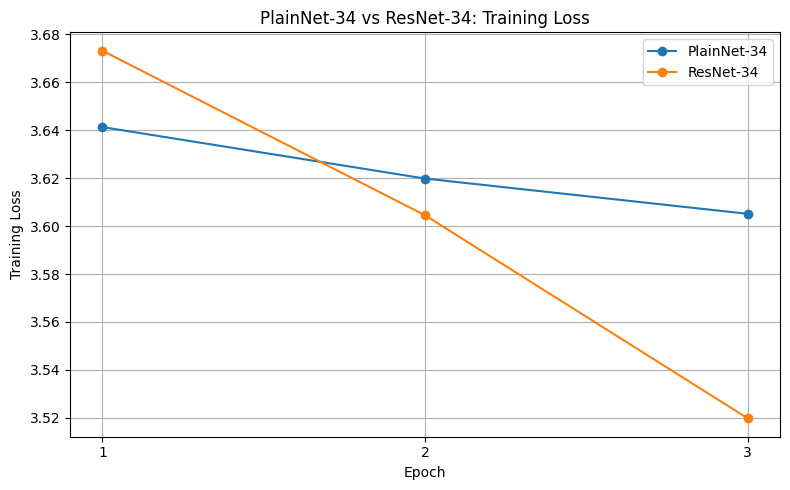

그래프 저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/figures/depth34_train_loss.png


In [8]:
#34층 모델 비교
#training loss
plot_pair_history(
    histories=histories,
    model_names=[
        "PlainNet-34",
        "ResNet-34",
    ],
    metric="train_loss",
    ylabel="Training Loss",
    title="PlainNet-34 vs ResNet-34: Training Loss",
    save_path=(
        FIGURE_DIR
        / "depth34_train_loss.png"
    ),
)

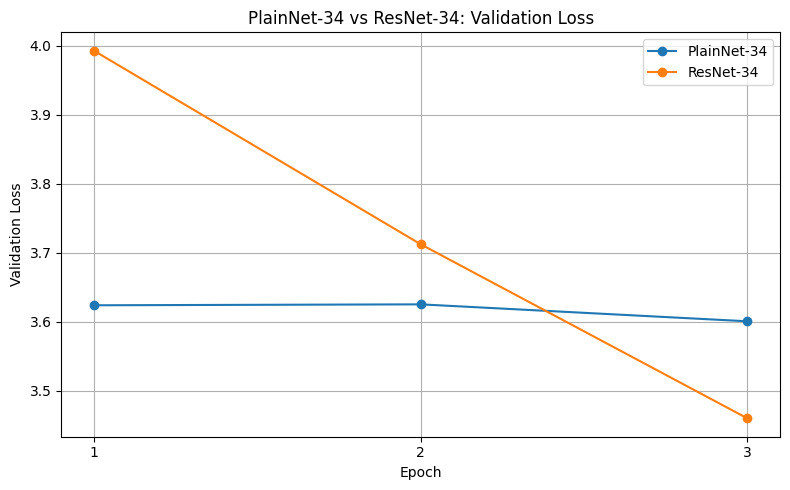

그래프 저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/figures/depth34_val_loss.png


In [9]:
#34층 validation loss
plot_pair_history(
    histories=histories,
    model_names=[
        "PlainNet-34",
        "ResNet-34",
    ],
    metric="val_loss",
    ylabel="Validation Loss",
    title="PlainNet-34 vs ResNet-34: Validation Loss",
    save_path=(
        FIGURE_DIR
        / "depth34_val_loss.png"
    ),
)

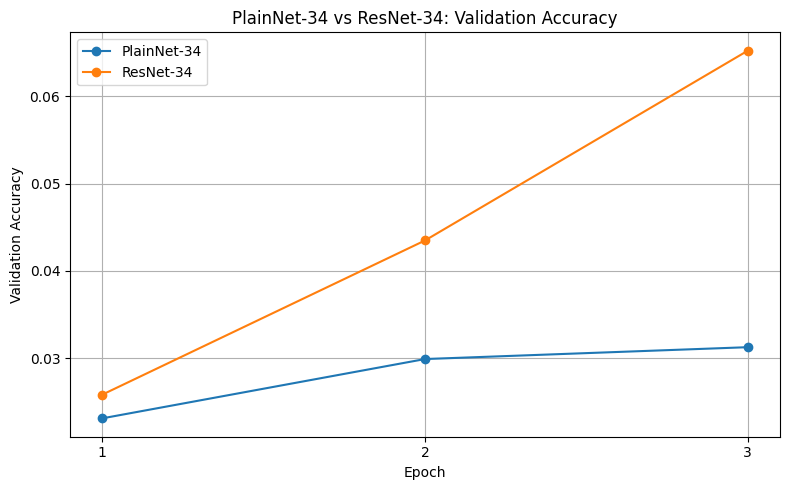

그래프 저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/figures/depth34_val_accuracy.png


In [10]:
#34층 vali. acc.
plot_pair_history(
    histories=histories,
    model_names=[
        "PlainNet-34",
        "ResNet-34",
    ],
    metric="val_accuracy",
    ylabel="Validation Accuracy",
    title="PlainNet-34 vs ResNet-34: Validation Accuracy",
    save_path=(
        FIGURE_DIR
        / "depth34_val_accuracy.png"
    ),
)

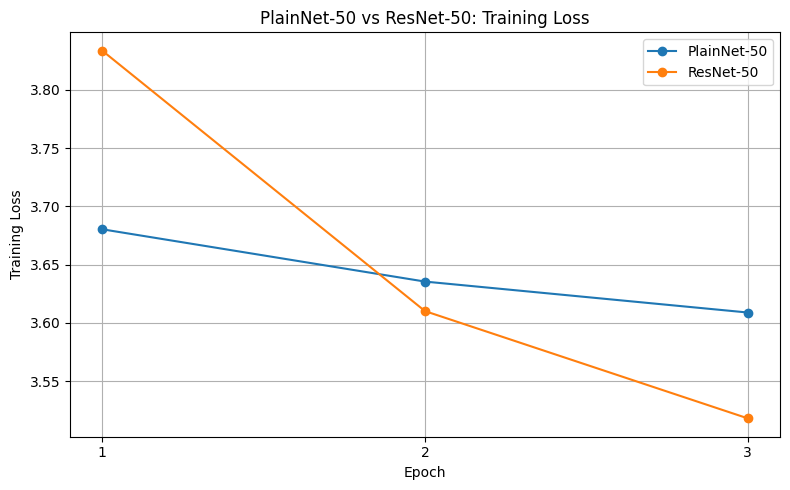

그래프 저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/figures/depth50_train_loss.png


In [11]:
#50층 모델 비교
#training
plot_pair_history(
    histories=histories,
    model_names=[
        "PlainNet-50",
        "ResNet-50",
    ],
    metric="train_loss",
    ylabel="Training Loss",
    title="PlainNet-50 vs ResNet-50: Training Loss",
    save_path=(
        FIGURE_DIR
        / "depth50_train_loss.png"
    ),
)

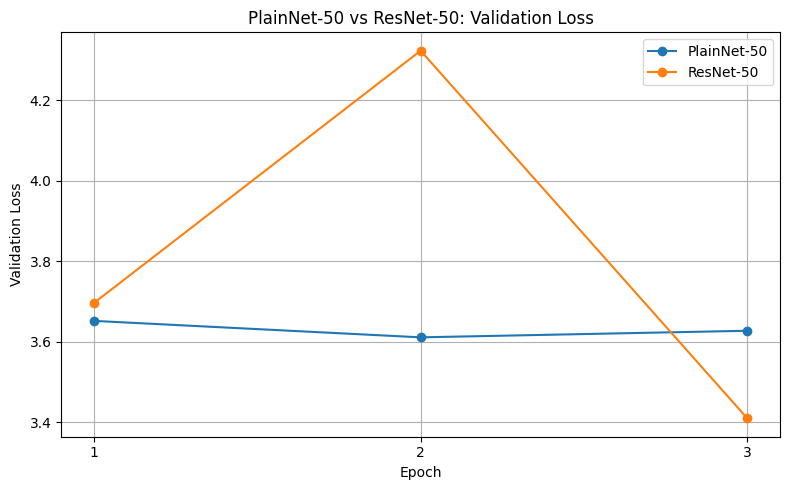

그래프 저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/figures/depth50_val_loss.png


In [12]:
#val
plot_pair_history(
    histories=histories,
    model_names=[
        "PlainNet-50",
        "ResNet-50",
    ],
    metric="val_loss",
    ylabel="Validation Loss",
    title="PlainNet-50 vs ResNet-50: Validation Loss",
    save_path=(
        FIGURE_DIR
        / "depth50_val_loss.png"
    ),
)

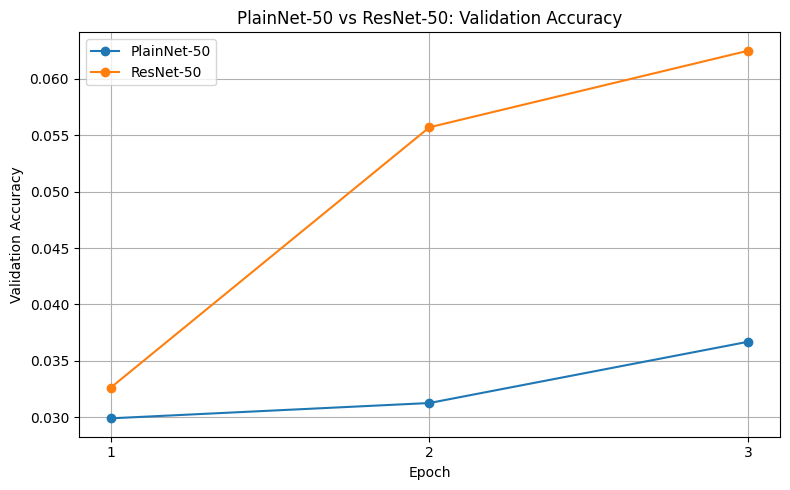

그래프 저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/figures/depth50_val_accuracy.png


In [13]:
#val_acc.
plot_pair_history(
    histories=histories,
    model_names=[
        "PlainNet-50",
        "ResNet-50",
    ],
    metric="val_accuracy",
    ylabel="Validation Accuracy",
    title="PlainNet-50 vs ResNet-50: Validation Accuracy",
    save_path=(
        FIGURE_DIR
        / "depth50_val_accuracy.png"
    ),
)

#최종 Ablation Study!

In [14]:
model_summary_records = []

for model_name, history in histories.items():
    model_summary_records.append({
        "model": model_name,
        "depth": (
            34 if "34" in model_name else 50
        ),
        "use_residual": (
            model_name.startswith("ResNet")
        ),
        "epochs": len(
            history["epoch"]
        ),
        "train_loss_start": (
            history["train_loss"][0]
        ),
        "train_loss_end": (
            history["train_loss"][-1]
        ),
        "train_loss_drop": (
            history["train_loss"][0]
            - history["train_loss"][-1]
        ),
        "final_train_accuracy": (
            history["train_accuracy"][-1]
        ),
        "best_epoch": (
            history["best_epoch"]
        ),
        "best_val_accuracy": (
            history["best_val_accuracy"]
        ),
        "best_val_loss": (
            history["best_val_loss"]
        ),
        "final_val_accuracy": (
            history["val_accuracy"][-1]
        ),
        "final_val_loss": (
            history["val_loss"][-1]
        ),
        "total_seconds": (
            history.get(
                "total_seconds"
            )
        ),
    })


model_result_df = pd.DataFrame(
    model_summary_records
).sort_values(
    by=["depth", "use_residual"]
)

model_result_df

,model,depth,use_residual,epochs,train_loss_start,train_loss_end,train_loss_drop,final_train_accuracy,best_epoch,best_val_accuracy,best_val_loss,final_val_accuracy,final_val_loss,total_seconds
0,PlainNet-34,34,False,3,3.641324,3.605124,0.036200,0.024117,3,0.031250,3.600949,0.031250,3.600949,489.051169
1,ResNet-34,34,True,3,3.673182,3.519790,0.153392,0.049592,3,0.065217,3.460321,0.065217,3.460321,110.204177
2,PlainNet-50,50,False,3,3.680336,3.608871,0.071465,0.029552,3,0.036685,3.627062,0.036685,3.627062,111.861957
3,ResNet-50,50,True,3,3.833673,3.518000,0.315673,0.059443,3,0.062500,3.409312,0.062500,3.409312,113.481918


In [15]:
MODEL_RESULT_PATH = (
    RESULT_DIR
    / "final_model_results.csv"
)

model_result_df.to_csv(
    MODEL_RESULT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("저장 완료:", MODEL_RESULT_PATH)

저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/results/final_model_results.csv


In [16]:
#Residual Connection의 효능...
ablation_records = []

for depth in [34, 50]:
    plain_name = f"PlainNet-{depth}"
    resnet_name = f"ResNet-{depth}"

    plain_history = histories[plain_name]
    resnet_history = histories[resnet_name]

    accuracy_gain = (
        resnet_history["best_val_accuracy"]
        - plain_history["best_val_accuracy"]
    )

    loss_change = (
        resnet_history["best_val_loss"]
        - plain_history["best_val_loss"]
    )

    ablation_records.append({
        "depth": depth,
        "plainnet_best_val_accuracy": (
            plain_history[
                "best_val_accuracy"
            ]
        ),
        "resnet_best_val_accuracy": (
            resnet_history[
                "best_val_accuracy"
            ]
        ),
        "residual_accuracy_gain": (
            accuracy_gain
        ),
        "residual_accuracy_gain_pp": (
            accuracy_gain * 100
        ),
        "plainnet_best_val_loss": (
            plain_history[
                "best_val_loss"
            ]
        ),
        "resnet_best_val_loss": (
            resnet_history[
                "best_val_loss"
            ]
        ),
        "resnet_minus_plainnet_loss": (
            loss_change
        ),
    })


ablation_result_df = pd.DataFrame(
    ablation_records
)

ablation_result_df

,depth,plainnet_best_val_accuracy,resnet_best_val_accuracy,residual_accuracy_gain,residual_accuracy_gain_pp,plainnet_best_val_loss,resnet_best_val_loss,resnet_minus_plainnet_loss
0,34,0.031250,0.065217,0.033967,3.396739,3.600949,3.460321,-0.140628
1,50,0.036685,0.062500,0.025815,2.581522,3.627062,3.409312,-0.217750


In [17]:
ABLATION_RESULT_PATH = (
    RESULT_DIR
    / "ablation_comparison.csv"
)

ablation_result_df.to_csv(
    ABLATION_RESULT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("저장 완료:", ABLATION_RESULT_PATH)

저장 완료: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/EX03_resnet_ablation/results/ablation_comparison.csv


###메모
결과 해석 원칙:

Training loss 감소
→ 모델의 가중치가 데이터에 맞게 갱신되었는가


Validation accuracy
→ 학습하지 않은 데이터의 품종을 얼마나 맞혔는가


PlainNet 대비 ResNet 차이
→ 같은 깊이에서 residual connection이 학습에 어떤 영향을 주었는가



> 본 실험은 제한된 epoch에서 residual connection 유무에 따른 초기 학습 특성을 비교한 결과이며, 각 모델의 최종 수렴 성능을 증명하는 실험은 아니다.



# 결론 및 회고

## 실험 결과

동일한 깊이와 학습 조건에서 residual connection의 유무를 비교한 결과,
ResNet은 PlainNet보다 더 큰 training loss 감소와 높은 validation
accuracy를 보였다.

| Depth | PlainNet Best Val Acc | ResNet Best Val Acc | 차이 |
|---:|---:|---:|---:|
| 34 | 3.13% | 6.52% | +3.40%p |
| 50 | 3.67% | 6.25% | +2.58%p |

34층 비교에서는 ResNet-34가 PlainNet-34보다 validation 이미지
25개를 더 맞혔고, 50층 비교에서는 ResNet-50이 PlainNet-50보다
19개를 더 맞혔다.

PlainNet의 최종 training loss는 37개 클래스의 균등 예측 기준인
약 3.61 부근에 머물렀지만, ResNet-34와 ResNet-50의 loss는
각각 약 3.52까지 감소했다. 이는 제한된 3 epoch 조건에서
residual connection을 사용한 모델이 더 빠르게 최적화되기
시작했음을 보여준다.

## 해석

Residual connection은 주 경로에서 학습한 F(x)에 입력 x를 더해
정보와 gradient가 통과할 수 있는 추가 경로를 제공한다.

따라서 깊은 모델이 모든 변환을 새로 학습해야 하는 PlainNet과 달리,
ResNet은 필요한 변화인 residual F(x)에 집중하고 불필요한 변환은
0에 가깝게 학습할 수 있다.

이번 실험 결과는 residual connection이 깊은 네트워크의 초기 학습을
더 안정적으로 만든다는 가설을 지지한다.

## 한계

본 실험은 3 epoch와 단일 seed에서 수행했으므로 각 모델의 최종
수렴 성능을 의미하지 않는다.

보다 신뢰도 높은 결론을 위해서는 여러 seed 반복 실험, 충분한 epoch,
learning-rate scheduler 적용 및 보존한 공식 test split을 이용한
최종 평가가 필요하다.

## 회고

이번 프로젝트를 통해 논문의 모델 구조를 읽는 것에서 그치지 않고,
BasicBlock과 BottleneckBlock을 직접 구현하여 전체 네트워크를
구성하는 과정을 경험했다.

또한 동일한 조건을 통제하고 특정 구조만 제거해 비교하는
Ablation Study의 목적과, loss와 accuracy가 서로 다른 정보를
보여준다는 점을 실제 학습 결과를 통해 확인했다.